In [2]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import soundfile as sf
import scipy.signal as sp
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime, timedelta

project_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(
    project_root
)  # \real_data_analysis\fiberscope_groix\src\data_processing
root_data = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\data"
)
root_bathy_data = os.path.join(project_root, "data", "bathy")
from publication.publication_figure import PubFigure, set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.utils import *

PubFigure()

# Illustration de la portion1 event2

## Chargement des données 

In [3]:
# ======================================================================================================================
# Chargement des données
# ======================================================================================================================
# Read wav dataset
ds_wav = xr.open_dataset(wav_dataset_fpath)
ds_wav

# Read source pos dataset
ds_src_pos = xr.open_dataset(source_position_dataset_fpath)
ds_src_pos

# Read OBS pos
df_obs_pos = pd.read_csv(
    obs_position_fpath,
    dtype={
        "obs_id": str,
        "lon": np.float64,
        "lat": np.float64,
    },
)
df_obs_pos

,obs_id,lon,lat
0,obs1,5.98821,43.03202
1,obs2,5.98822,43.03202
2,obs4,5.98822,43.03202
3,obs5,5.98821,43.03202
4,obs6,5.98820,43.03187
5,obs7,5.98950,43.03168


In [4]:
# L'objectif est de reproduire un cadre similaire à celui de l'article de Verlinden et al. 2015 :
#
# * Une trajectoire *library*
# * Une ou plusieurs trajectoires *event*

# OPTION 1 : croisement le plus proche (pour l'instant pas la donnée dispo)
lib_traj = {
    "start": 21900,
    "end": 22500,
    # "start": 35000,
    # "end": 4500,
}
event_1_traj = {
    "start": 2000,
    "end": 2800,
}
event_2_traj = {
    "start": 79300,
    "end": 80200,
}

# # OPTION 2 : croisement un peu plus loin
# lib_traj = {
#     "start": 54000,
#     "end": 55000,
# }
# event_1_traj = {
#     "start": 69800,
#     "end": 70800,
# }
# # event_1_traj = {
# #     "start": 65000,
# #     "end": 66000,
# # }
# event_2_traj = {
#     "start": 72300,
#     "end": 73300,
# }

Text(0, 0.5, 'Latitude [°]')

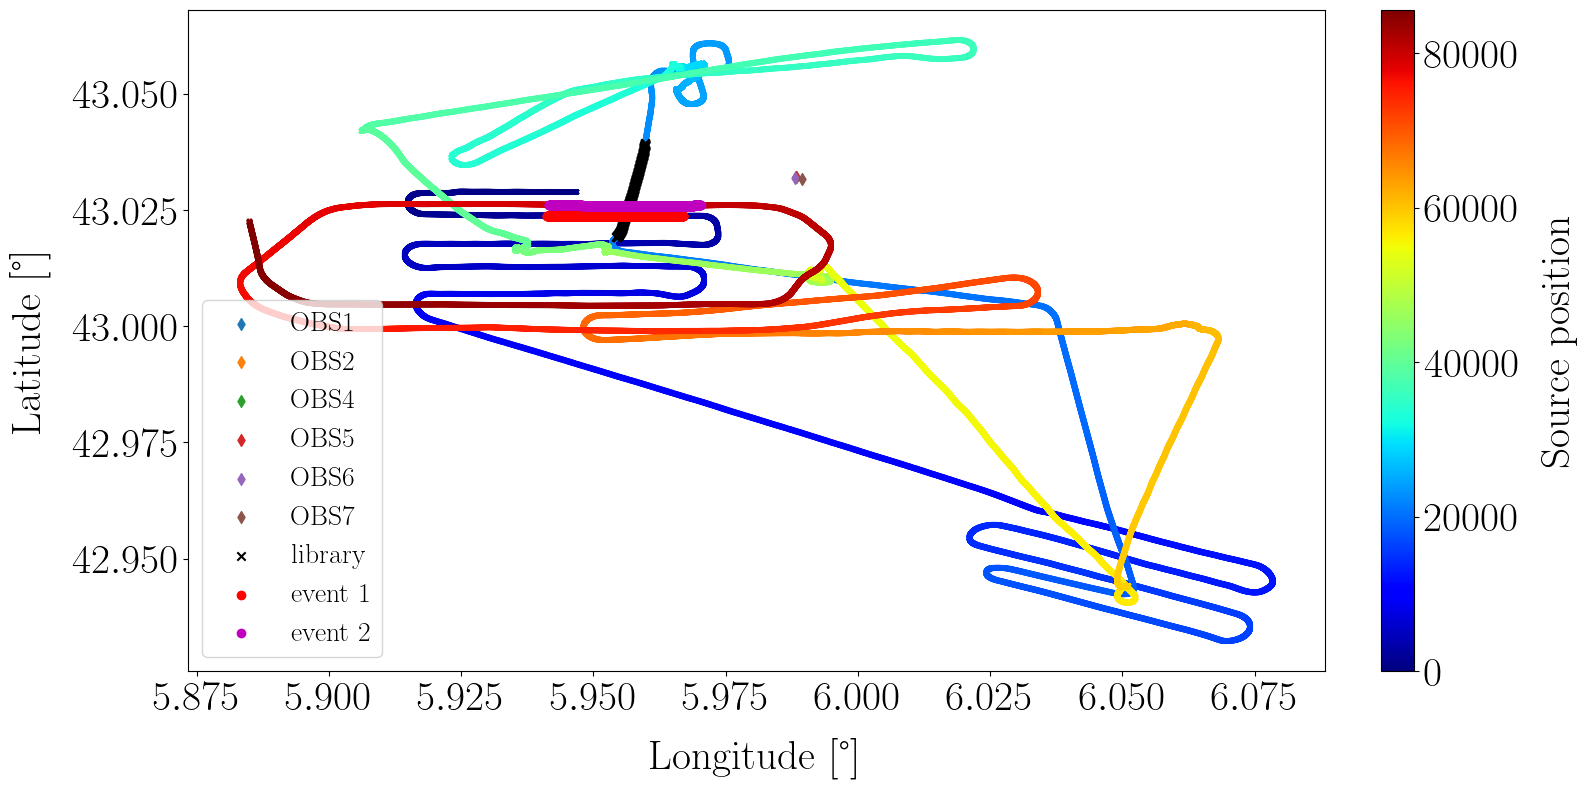

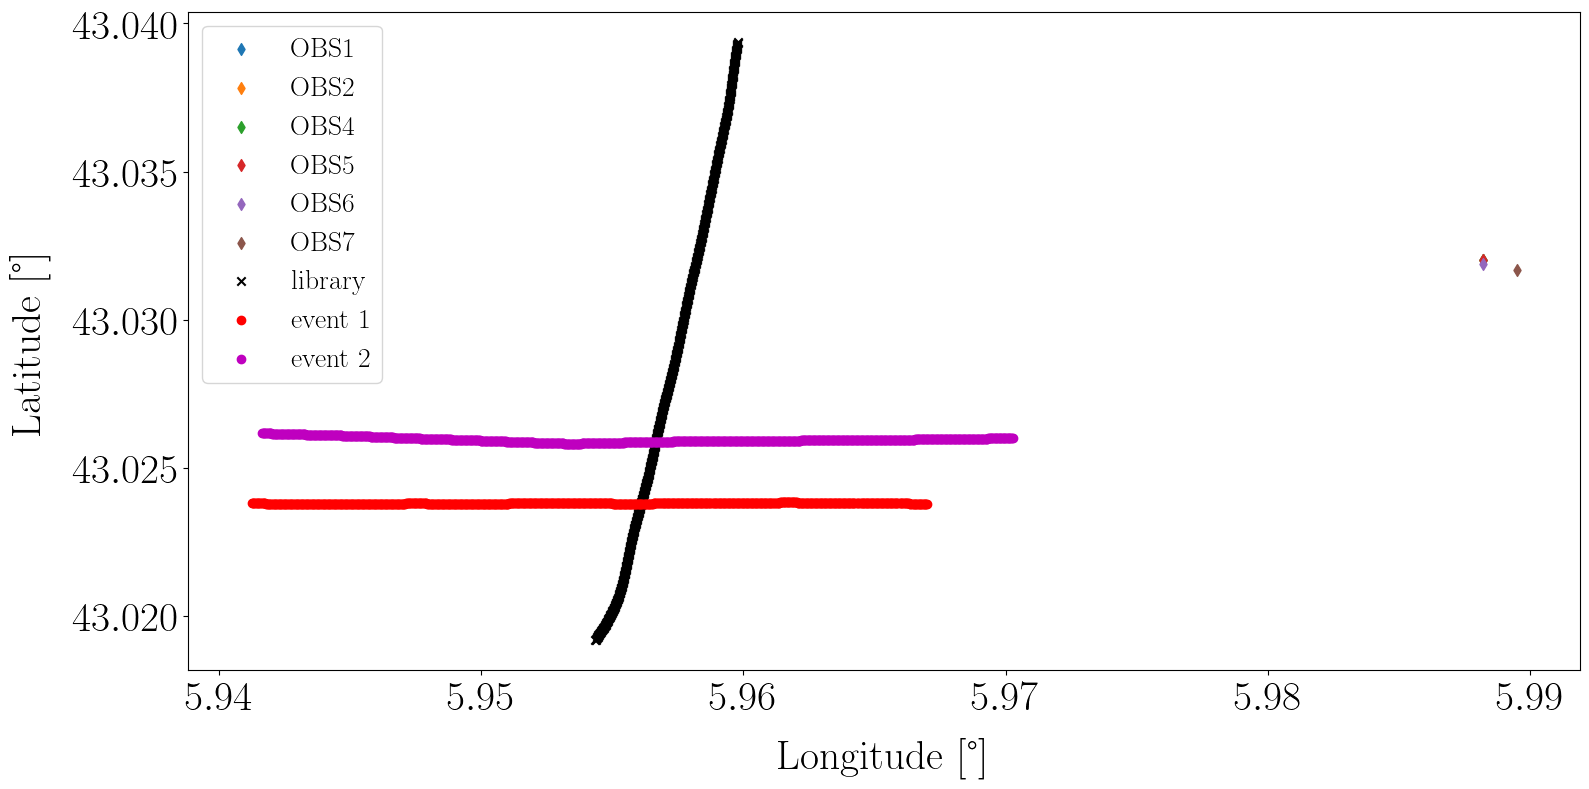

In [5]:
plt.figure()
for obs_id in df_obs_pos.obs_id:
    obs = df_obs_pos.loc[df_obs_pos["obs_id"] == obs_id]
    plt.scatter(obs.lon, obs.lat, marker="d", label=f"{obs.obs_id.values[0].upper()}")

sc = plt.scatter(
    ds_src_pos.lon,
    ds_src_pos.lat,
    cmap="jet",
    c=np.arange(ds_src_pos.time.size),
    marker="x",
    s=10,
)
# Library
lib_pos = ds_src_pos.isel(time=slice(lib_traj["start"], lib_traj["end"]))
plt.scatter(lib_pos.lon, lib_pos.lat, marker="x", color="k", label="library")
# Event
event_1_pos = ds_src_pos.isel(time=slice(event_1_traj["start"], event_1_traj["end"]))
plt.scatter(event_1_pos.lon, event_1_pos.lat, marker="o", color="r", label="event 1")
# Event 2
event_2_pos = ds_src_pos.isel(time=slice(event_2_traj["start"], event_2_traj["end"]))
plt.scatter(event_2_pos.lon, event_2_pos.lat, marker="o", color="m", label="event 2")
plt.colorbar(sc, label="Source position")
plt.legend()
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")
# plt.show()


plt.figure()
for obs_id in df_obs_pos.obs_id:
    obs = df_obs_pos.loc[df_obs_pos["obs_id"] == obs_id]
    plt.scatter(obs.lon, obs.lat, marker="d", label=f"{obs.obs_id.values[0].upper()}")

plt.scatter(lib_pos.lon, lib_pos.lat, marker="x", color="k", label="library")
plt.scatter(event_1_pos.lon, event_1_pos.lat, marker="o", color="r", label="event 1")
plt.scatter(event_2_pos.lon, event_2_pos.lat, marker="o", color="m", label="event 2")
plt.legend()
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")
# plt.show()
# plt.close("all")

Event sequence 2 : from 2026-02-24_22-14-56 to 2026-02-24_22-29-56


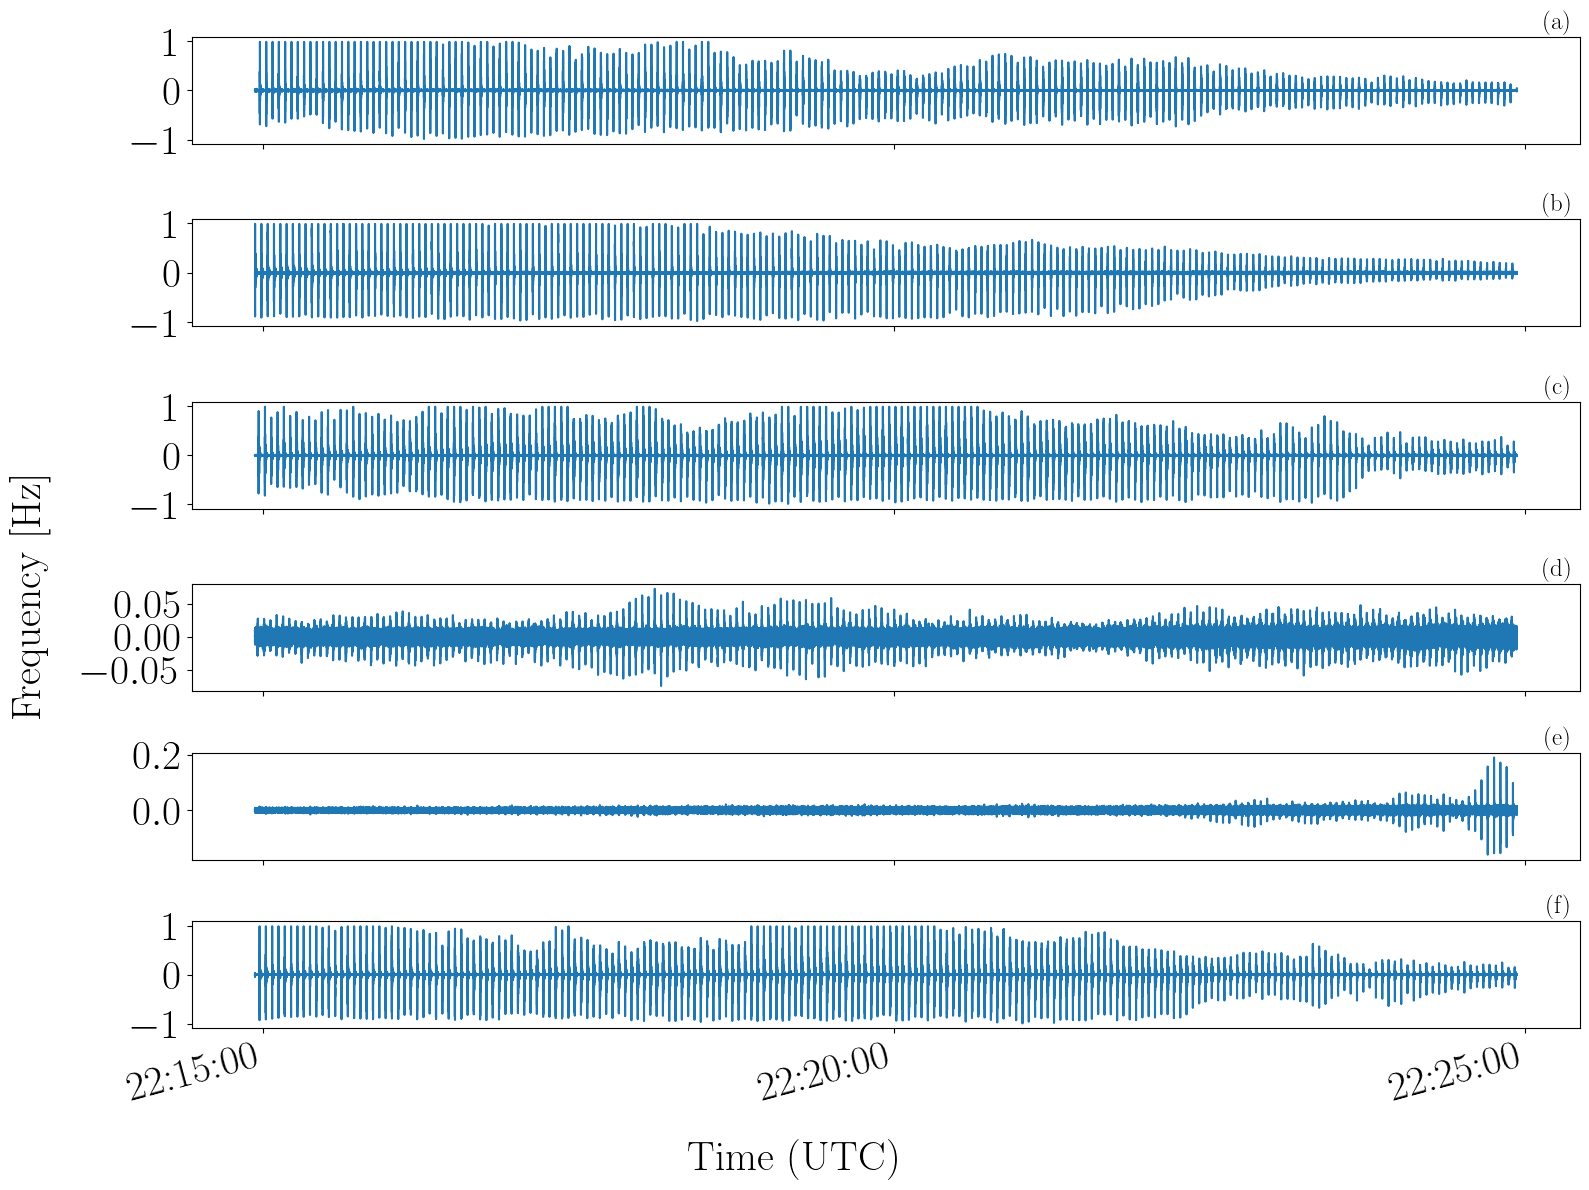

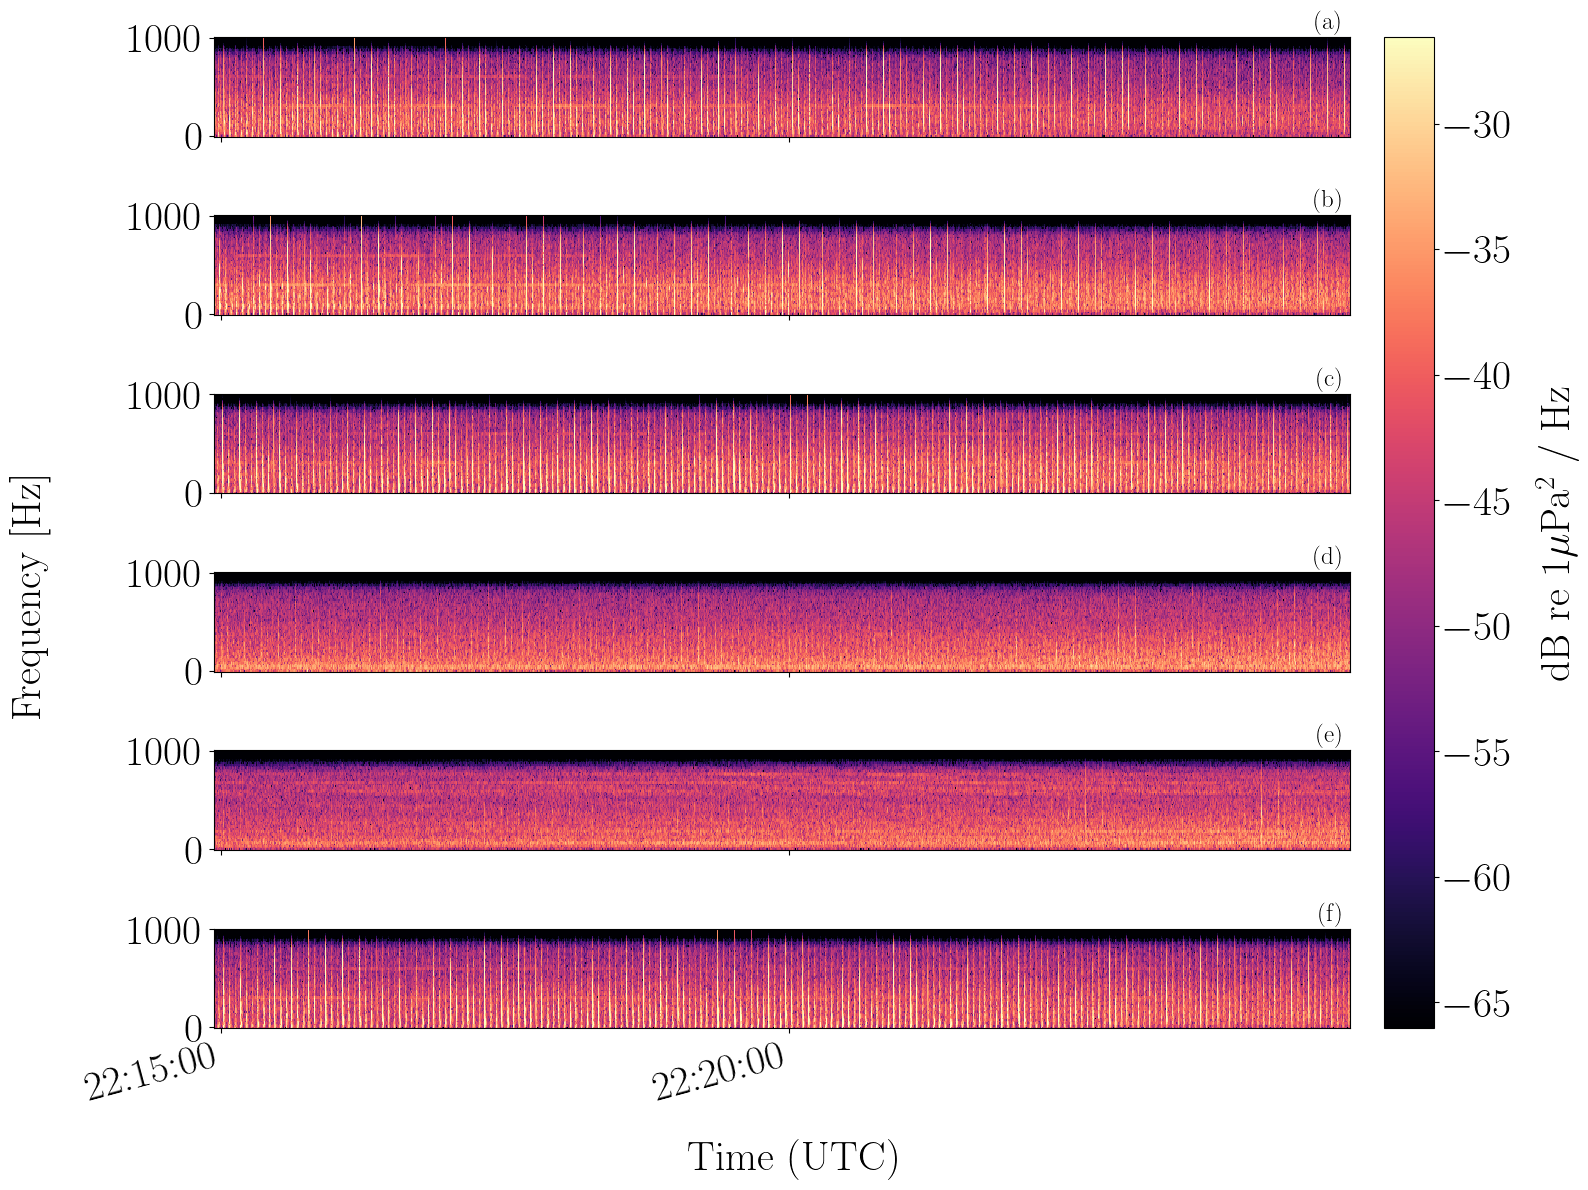

In [6]:
start_dt = event_2_pos.time.values[0]
start_dt = pd.to_datetime(str(start_dt)).strftime(datetime_format)
end_dt = event_2_pos.time.values[-1]
end_dt = pd.to_datetime(str(end_dt)).strftime(datetime_format)
print(f"Event sequence 2 : from {start_dt} to {end_dt}")
analysis_duration_s = 10 * 60

# start_dt = "2026-02-24_22-00-00"
# ds_wav_ = ds_wav.sel(obs_id=[4, 7])
plot_sequence(ds_wav, start_dt, analysis_duration_s, nperseg=2**7, alpha_overlap=0.75)

## Calcul des temps d'arrivée

C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:341: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:341: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:341: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\acouplane\src\utils.py:341: UserWarning: No artists with labels found to put in legend.  Note that artis

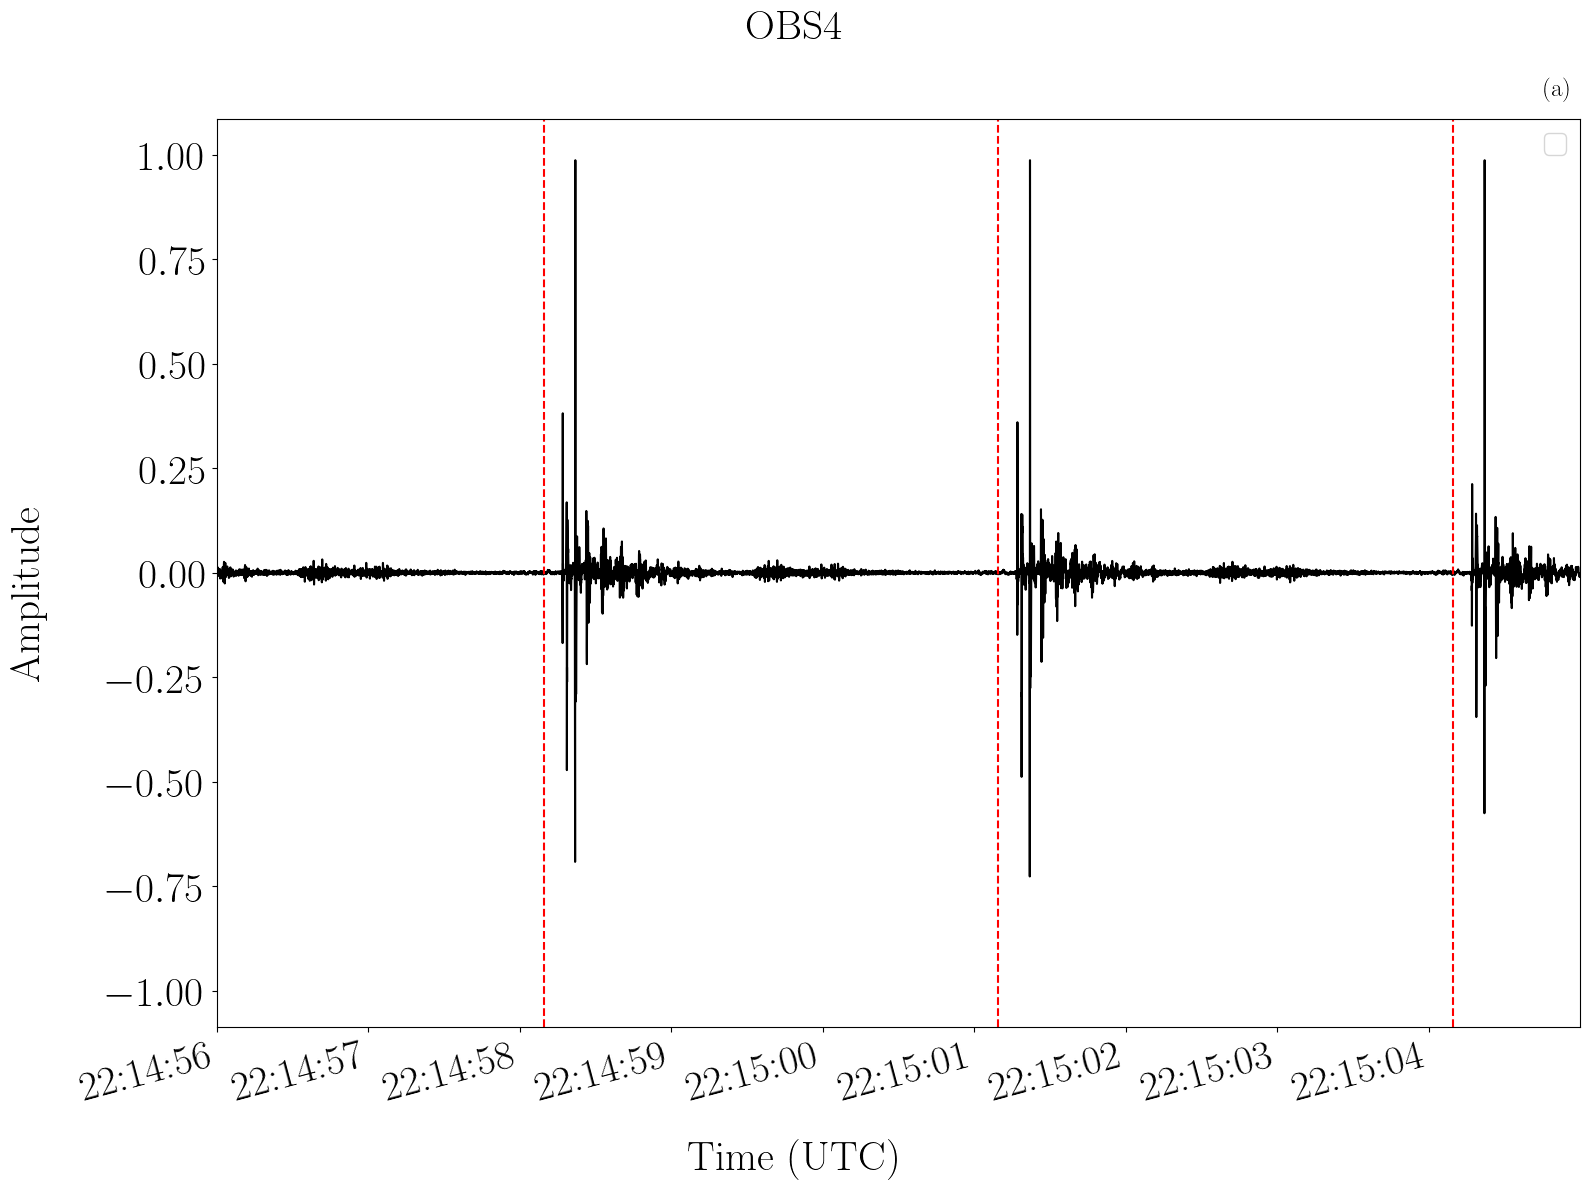

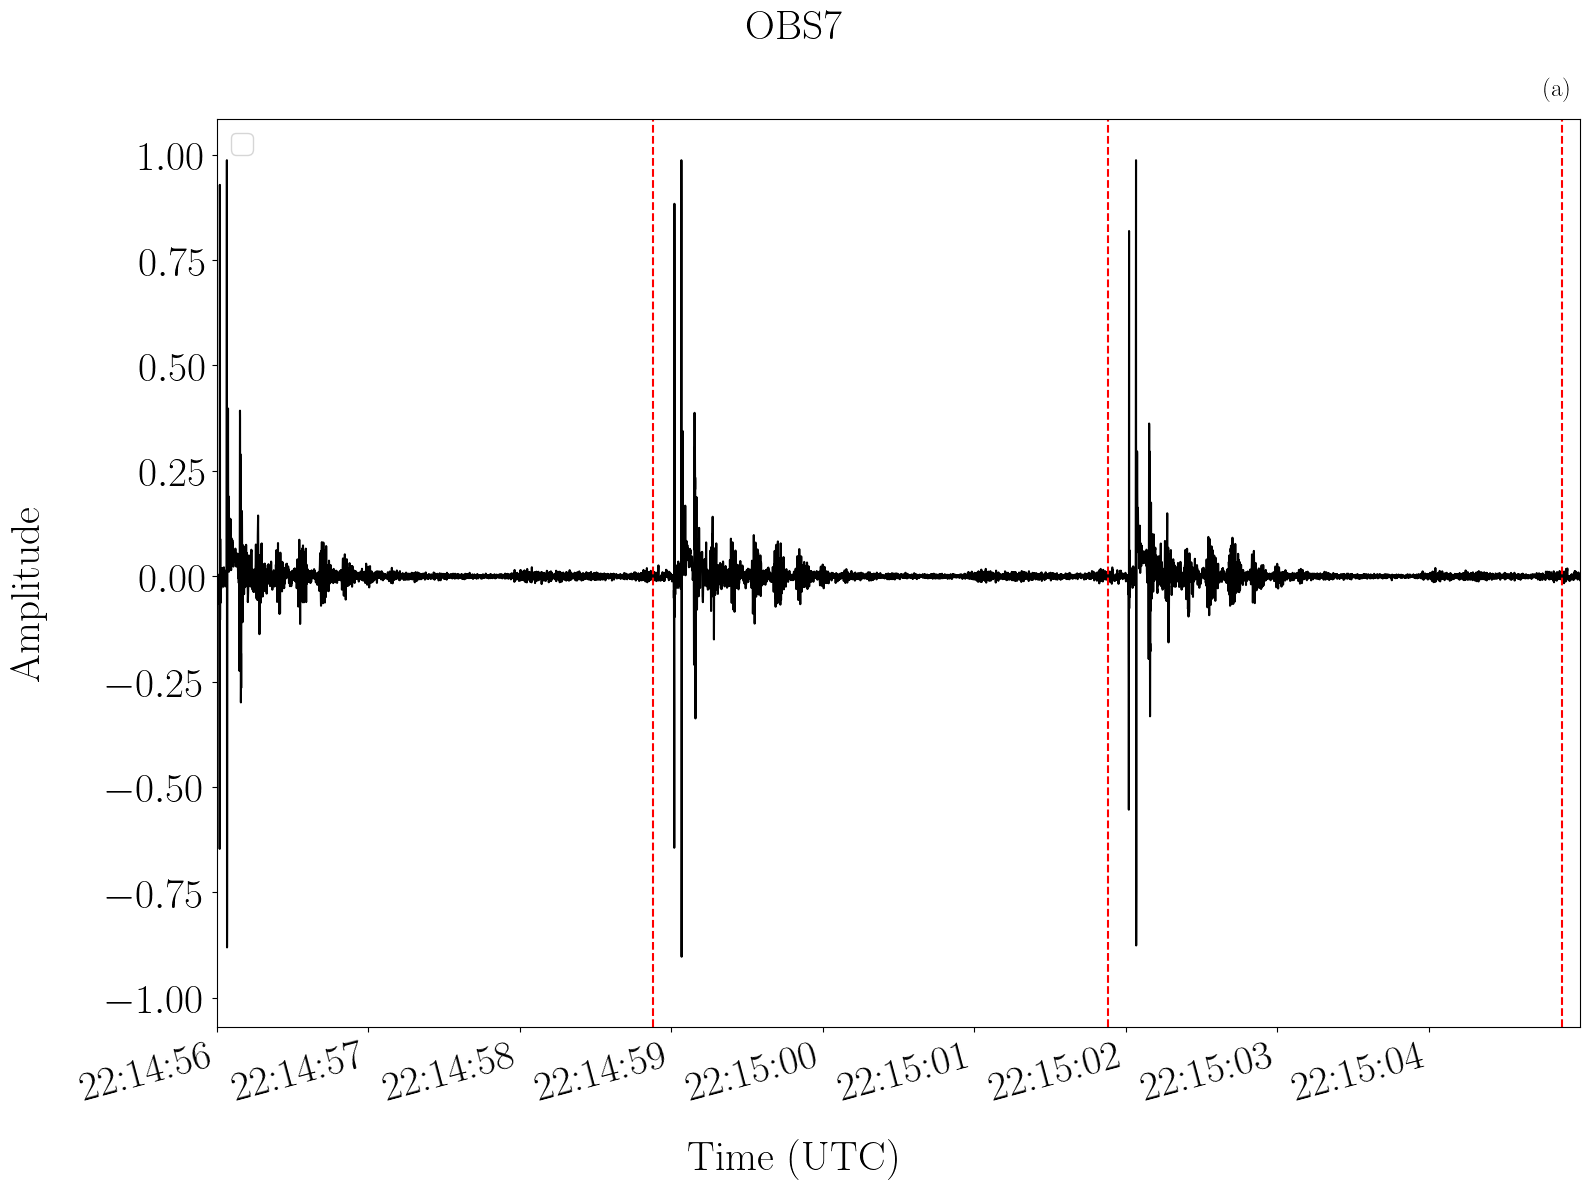

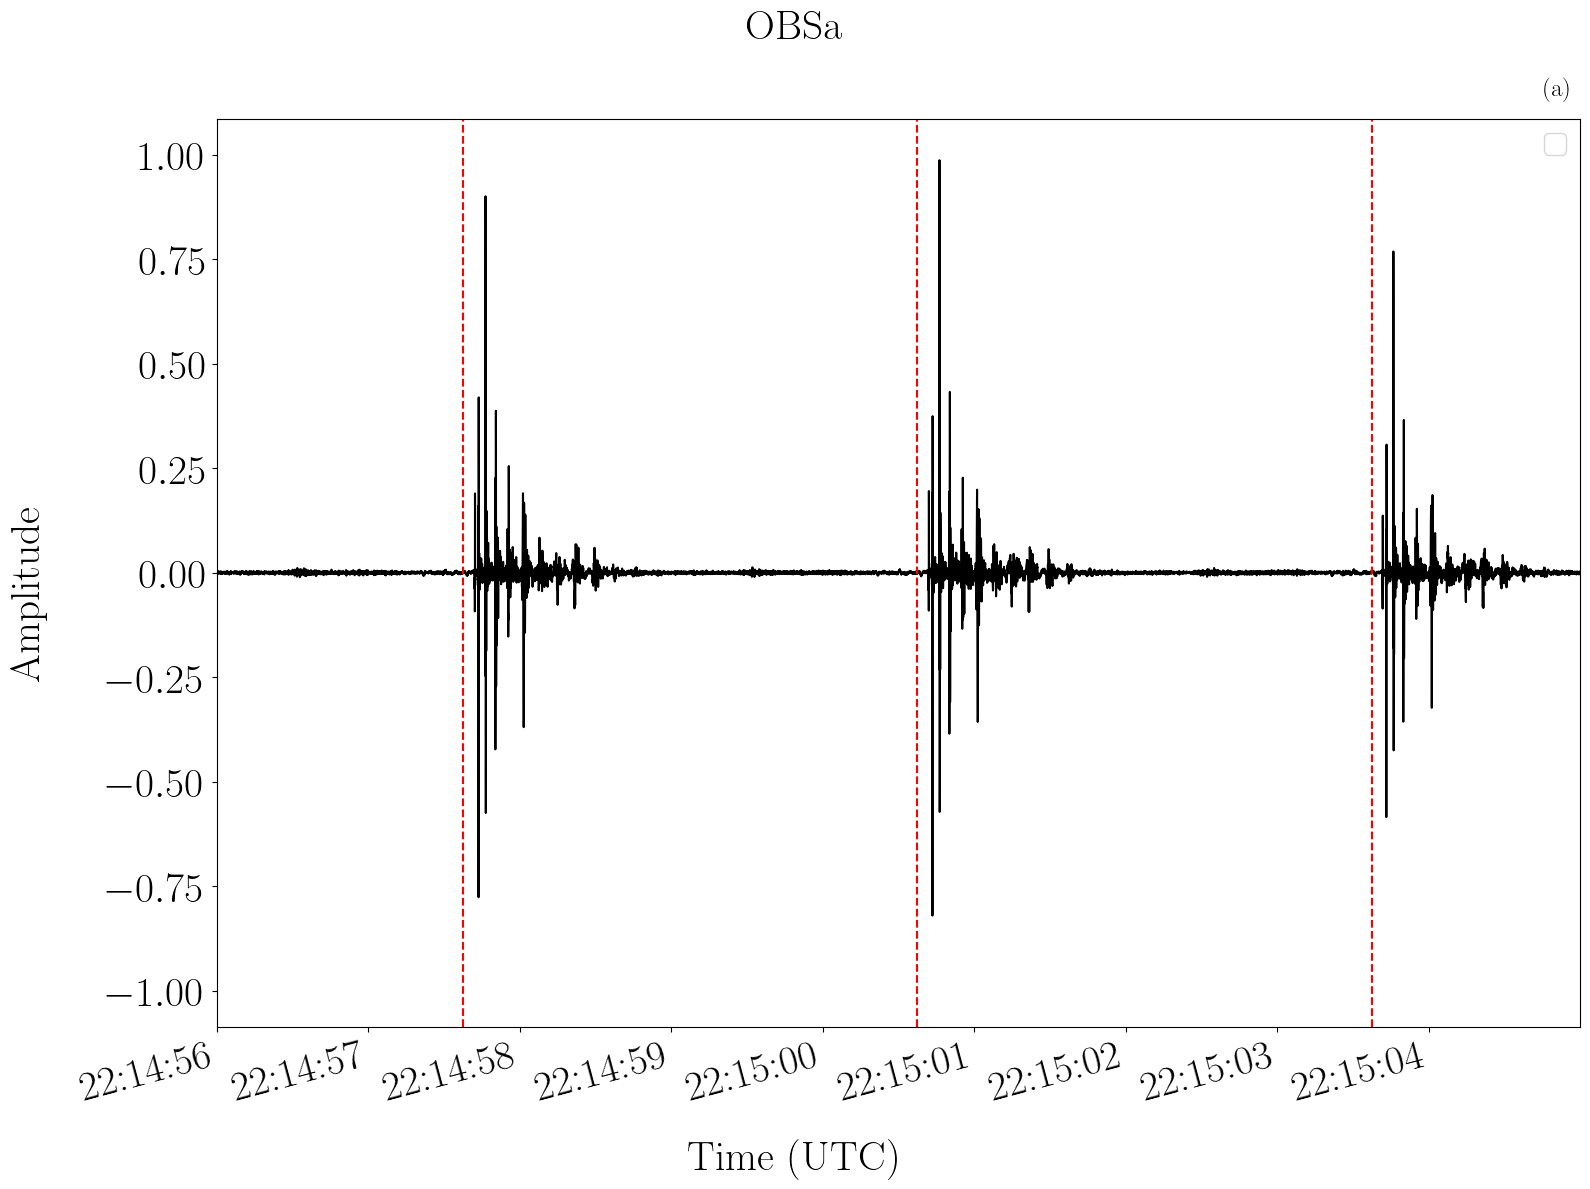

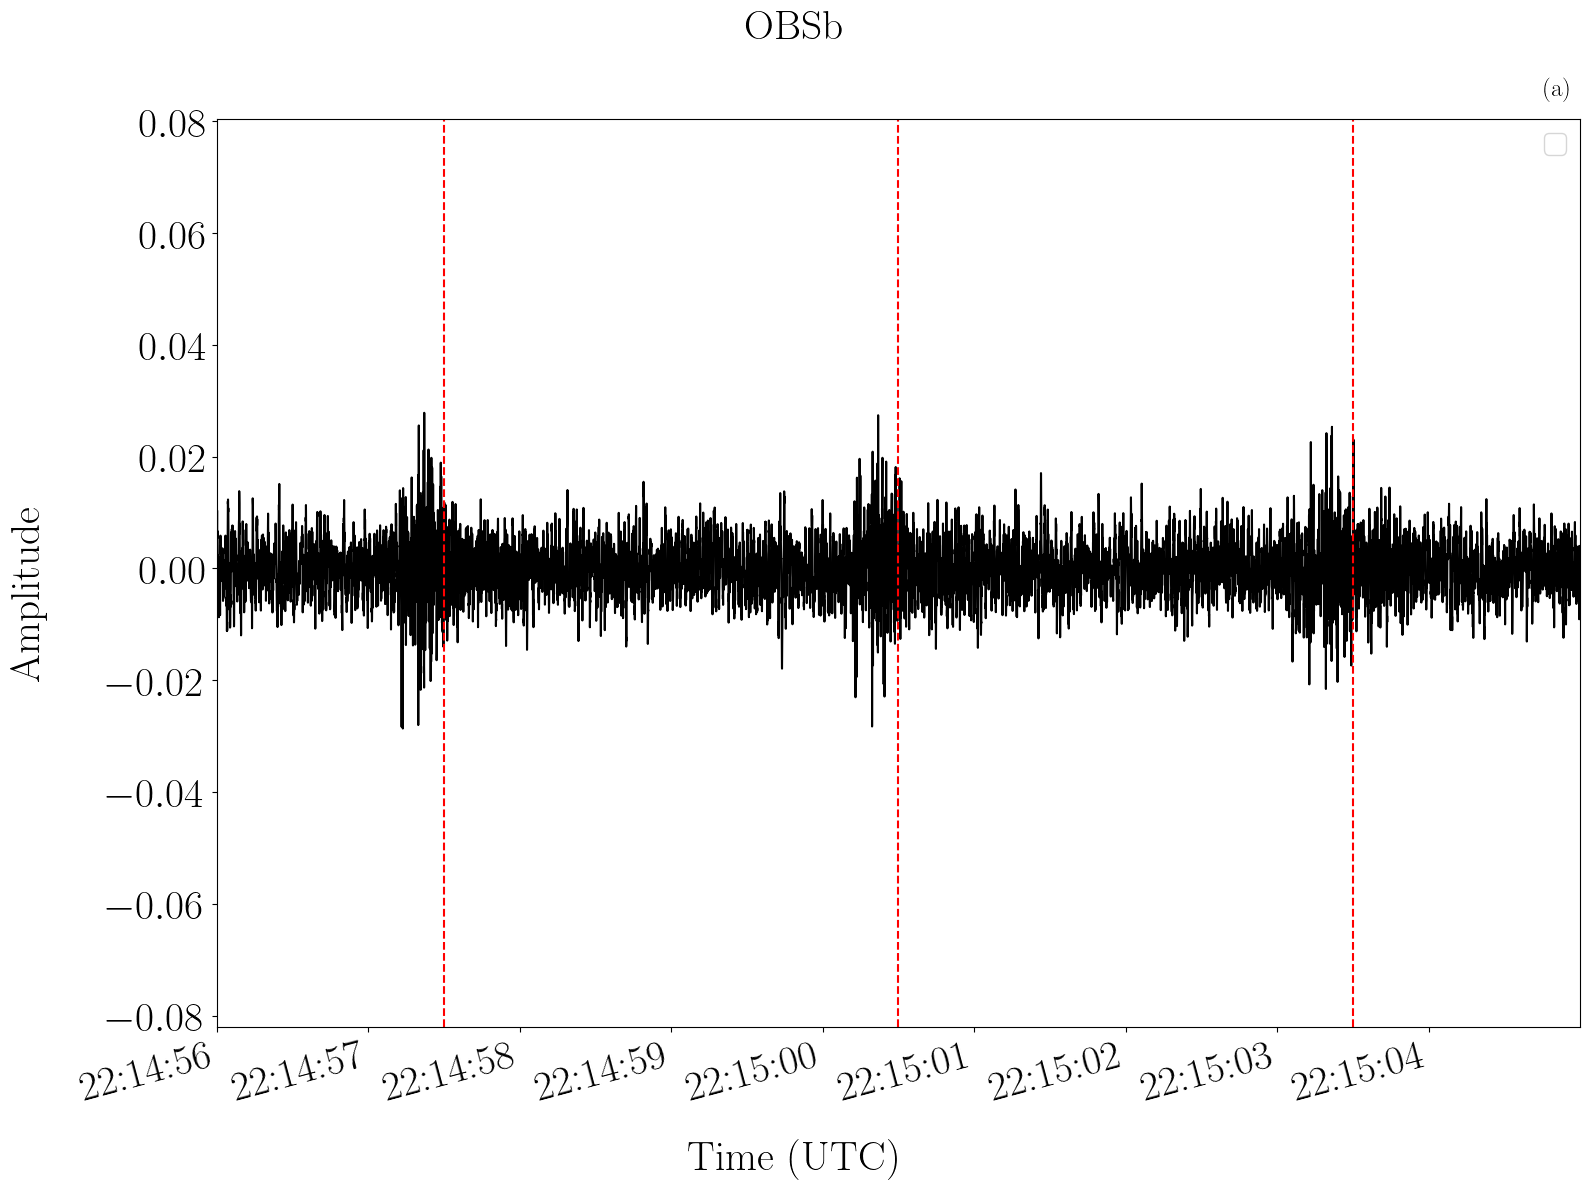

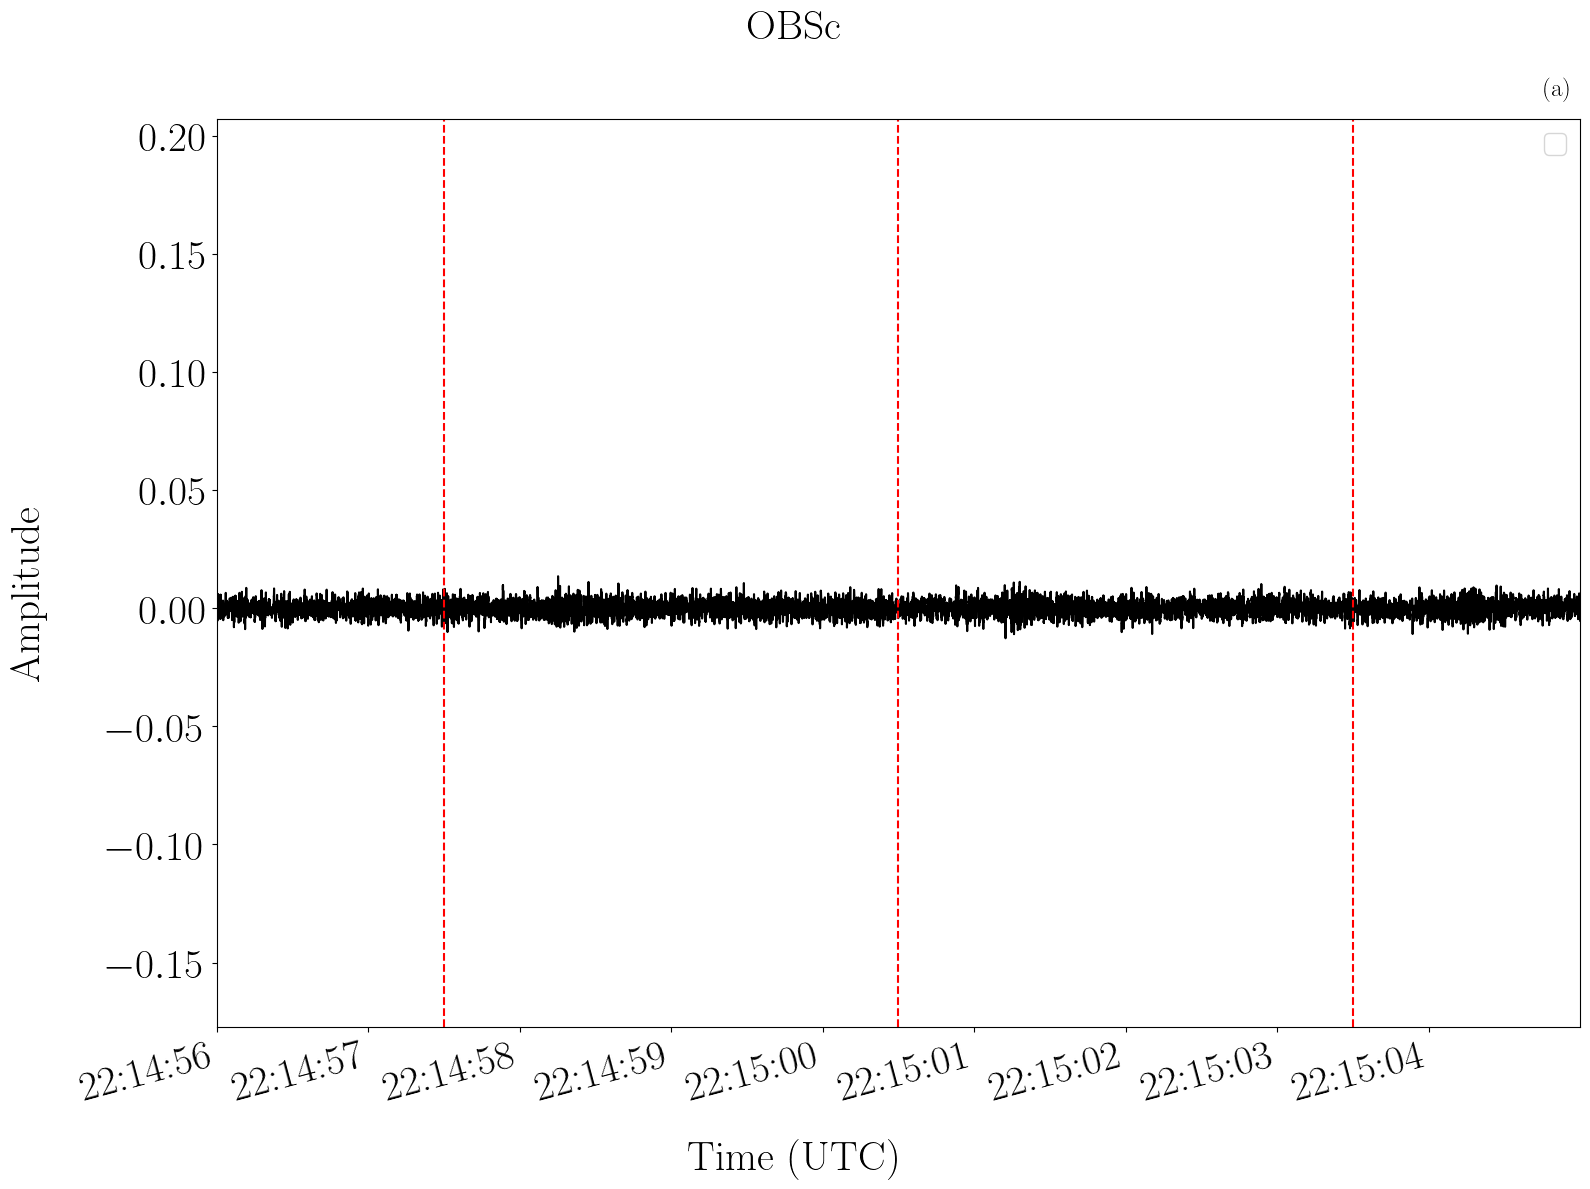

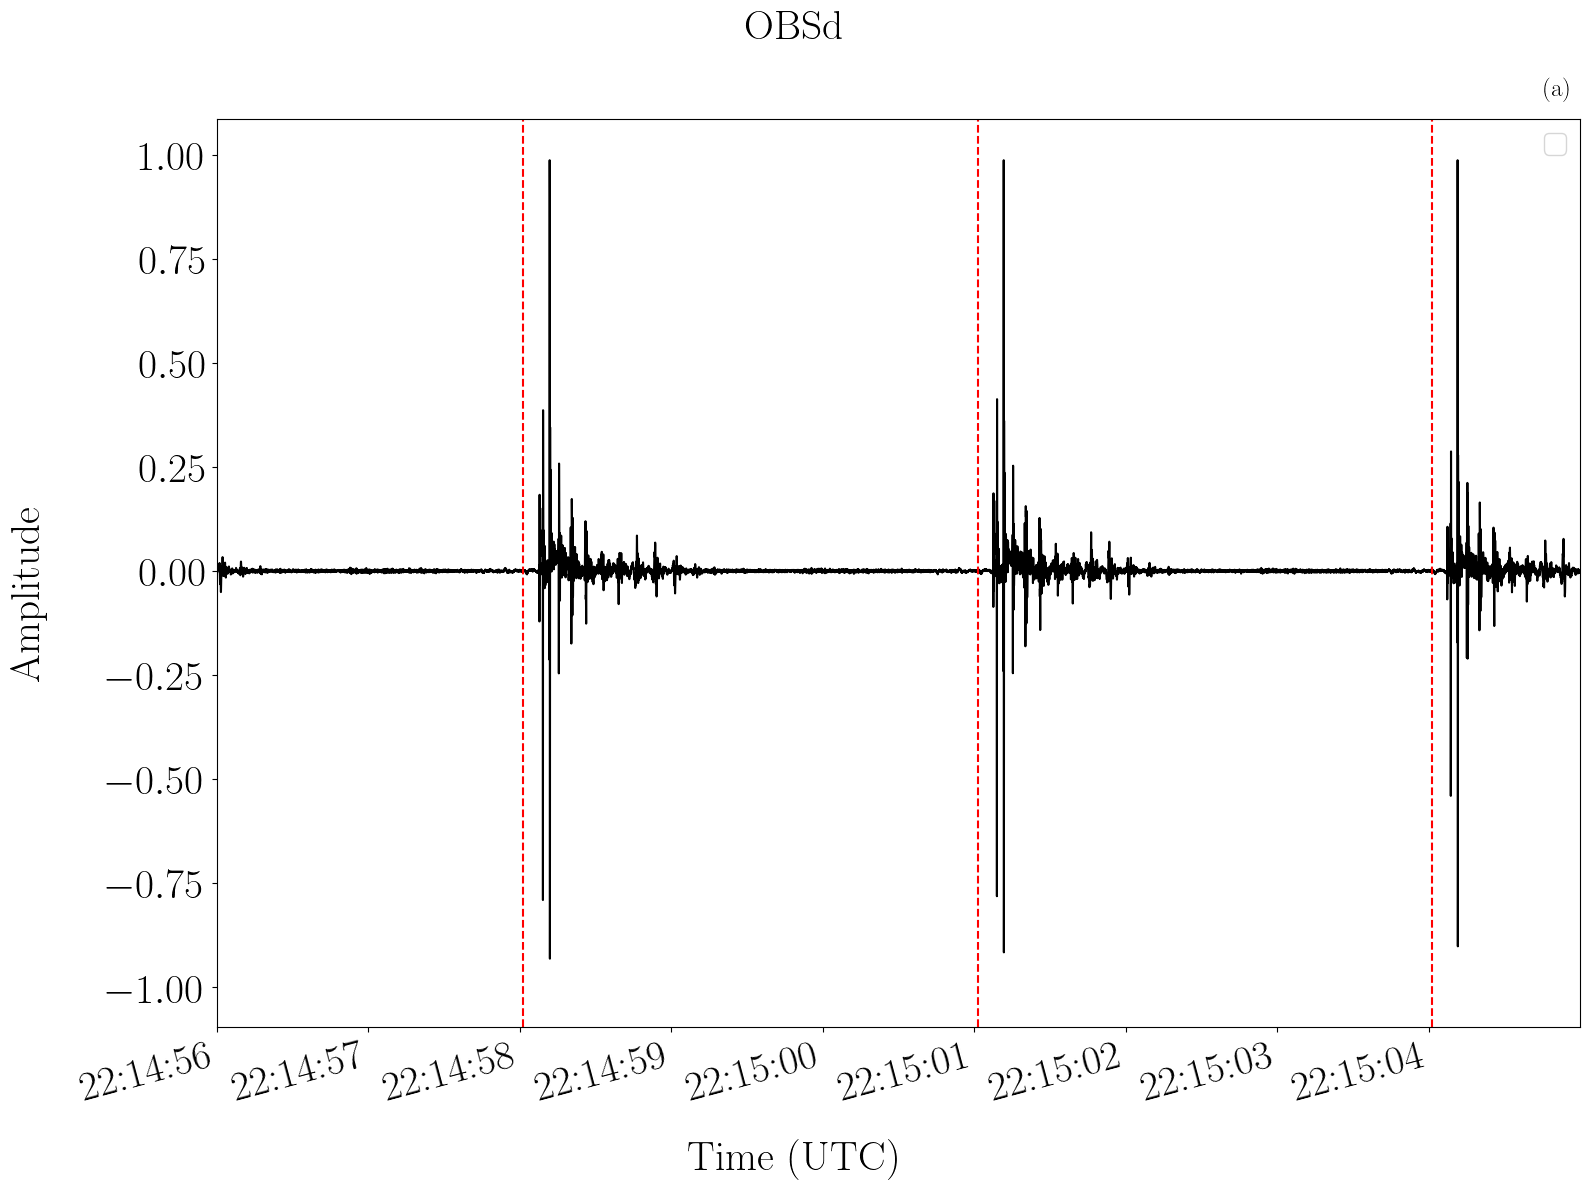

In [7]:
interval_inter_pulse_s = 3
sta_duration = 0.45
lta_duration = 3
sta_lta_threshold_obs4 = 0.5
sta_lta_threshold_obs7 = 0.5
sta_lta_threshold_obsa = 0.5
sta_lta_threshold_obsb = 0.5
sta_lta_threshold_obsc = 0.5
sta_lta_threshold_obsd = 0.5

thresholds = [
    sta_lta_threshold_obs4,
    sta_lta_threshold_obs7,
    sta_lta_threshold_obsa,
    sta_lta_threshold_obsb,
    sta_lta_threshold_obsc,
    sta_lta_threshold_obsd,
]

sig_dt, signals, arrivals_dt, arrivals_dt_idx = apply_sta_lta_only_first(
    ds_wav,
    sta_duration,
    lta_duration,
    start_dt,
    analysis_duration_s,
    thresholds,
    pulse_interval_s=interval_inter_pulse_s,
    fs=ds_wav.fs.isel(obs_id=0).values,
)
# plt.show()
# plt.close("all")

Les données des capteurs OBS b et c ont des très faibles SNR, en particulier en début de séquence. 

In [8]:
# Conversion en dataset xarray
arr_dt = np.array(arrivals_dt)
ds_arr = xr.Dataset(
    data_vars=dict(arr_dt=(["obs_id", "pulse_id"], arr_dt)),
    coords=dict(obs_id=ds_wav.obs_id.values, pulse_id=np.arange(arr_dt.shape[1])),
)

## Calcul Sxy SCOT 

In [9]:
def compute_sxy_scot(
    ds_arr,
    signals,
    times,
    num_obs,
    den_obs,
    ref_obs=None,
    window_mode="common",
    fs=2000,
    offset_s=0.1,
    pulse_len_s=None,
    nfft=2**16,
    n_smooth=5,
):
    """Estimate the Sxy_scot = S_{num,den} / sqrt(S_{num,num} S_{den,den}) for each pulse.


    Parameters
    ----------
    ds_arr, signals, times, fs, offset_s, pulse_len_s, window_mode, ref_obs
        See `extract_pulse_windows`.
    num_obs : list of str
        Sensors in the numerator (e.g. [4, 1, 6]).
    den_obs : str
        Sensor in the denominator (e.g. 7).
    nfft : int
        FFT length (zero-padding if larger than the window).
    n_smooth : int
        Length of the moving average applied to the RTF magnitude in dB.

    Returns
    -------
    _type_
        _description_

    """

    all_obs = list(dict.fromkeys([*num_obs, den_obs, *(ref_obs or [])]))
    windows, idx_start = extract_pulse_windows(
        ds_arr,
        {o: signals[o] for o in all_obs},
        times,
        fs,
        offset_s,
        pulse_len_s,
        window_mode=window_mode,
        ref_obs=ref_obs,
    )

    # Remove last to avoid nan
    for o in all_obs:
        idx_start[o] = idx_start[o][:-1]
        windows[o] = windows[o][:-1]

    freq = np.fft.rfftfreq(nfft, d=1 / fs)
    fft = {o: np.fft.rfft(windows[o], n=nfft, axis=-1) for o in all_obs}

    # Auto-spectrums
    s_den = fft[den_obs] * np.conj(fft[den_obs])
    sxy_scot = np.stack(
        [
            (fft[o] * np.conj(fft[den_obs]))
            / (np.sqrt(s_den * fft[o] * np.conj(fft[o])) + 1e-12)
            for o in num_obs
        ]
    )

    # Compute
    # sxy = []
    cxy_ = []
    y = windows[den_obs]
    for o in num_obs:
        x = windows[o]
        n = x.shape[1]
        nfft = 2 * n - 1  # Zero pad to compute full correlation

        x_fft = np.fft.fft(x, n=nfft, axis=1)
        y_fft = np.fft.fft(y, n=nfft, axis=1)

        # # Sxy
        # sxy_o = x_fft * np.conj(y_fft)

        c_xy = np.fft.ifft(x_fft * np.conj(y_fft), axis=1)
        c_xy = np.real(c_xy)
        c_xy = np.fft.fftshift(c_xy, axes=1)
        # c_xy = sp.correlate(x, y, axis=1)

        cxy_.append(c_xy)

    tau = sp.correlation_lags(x.shape[1], y.shape[1], mode="full") * 1/fs
    cxy = np.stack(cxy_)
    

    rtf_id = [f"{o}/{den_obs}" for o in num_obs]
    dims = ("rtf_id", "pulse_id", "freq")
    return xr.Dataset(
        data_vars=dict(
            sxy_scot=(dims, sxy_scot),
            cxy=(("rtf_id", "pulse_id", "lag"), cxy),
            idx_start=(
                ("obs_id", "pulse_id"),
                np.stack([idx_start[o] for o in all_obs]),
            ),
        ),
        coords=dict(
            rtf_id=rtf_id,
            obs_id=all_obs,
            pulse_id=np.arange(windows[all_obs[0]].shape[0]),
            freq=freq,
            lag=tau,
        ),
        attrs=dict(
            fs=fs,
            offset_s=offset_s,
            nfft=nfft,
            den_obs=den_obs,
            window_mode=window_mode,
            n_smooth=n_smooth,
        ),
    )

In [10]:
def plot_sxy_map(
    ds_dcf,
    rtf_id,
    window_mode,
    freq_lim=(10, 800),
    percentiles=(5, 95),
    cmap="magma",
    ax=None,
):
    """Plot the sxy magnitude [dB] as a (pulse_id, frequency) map.

    Parameters
    ----------
    ds_dcf : xr.Dataset
        Output of `compute_sxy_scot`, concatenated along "window_mode".
    rtf_id : str
        RTF to display (e.g. "4/7").
    window_mode : str
        Window option to display ("common" or "shifted").
    freq_lim : tuple of float
        Frequency limits [Hz] of the plot.
    percentiles : tuple of float
        Percentiles of the data used as color limits.
    """
    da_real = np.real(ds_dcf["sxy_scot"].sel(rtf_id=rtf_id))
    da_imag = np.imag(ds_dcf["sxy_scot"].sel(rtf_id=rtf_id))

    vmin, vmax = np.nanpercentile(da_real.values, percentiles)

    _, axs = plt.subplots(1, 2, figsize=(16, 8))

    im = axs[0].pcolormesh(
        da_real["freq"],
        da_real["pulse_id"],
        da_real.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    im = axs[1].pcolormesh(
        da_imag["freq"],
        da_imag["pulse_id"],
        da_imag.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    for ax in axs.flatten():
        ax.set_xlim(*freq_lim)
        ax.set_xlabel("Frequency [Hz]")
        ax.set_ylabel("Replica ID")
        ax.set_title(f"RTF {rtf_id}")
        ax.figure.colorbar(im, ax=ax, label="Magnitude [dB]")
        
    return ax

In [11]:
def plot_cxy_map(
    ds_dcf,
    rtf_id,
    window_mode,
    freq_lim=(10, 800),
    percentiles=(5, 95),
    cmap="jet",
    ax=None,
):
    """Plot the sxy magnitude [dB] as a (pulse_id, frequency) map.

    Parameters
    ----------
    ds_dcf : xr.Dataset
        Output of `compute_sxy_scot`, concatenated along "window_mode".
    rtf_id : str
        RTF to display (e.g. "4/7").
    window_mode : str
        Window option to display ("common" or "shifted").
    freq_lim : tuple of float
        Frequency limits [Hz] of the plot.
    percentiles : tuple of float
        Percentiles of the data used as color limits.
    """
    cxy = np.abs(ds_dcf["cxy"].sel(rtf_id=rtf_id))

    vmin, vmax = np.nanpercentile(cxy.values, percentiles)

    # _, ax = plt.subplots(1, 1, figsize=(16, 8))

    plt.figure()
    cxy.plot(vmin=vmin, vmax=vmax, cmap=cmap, ax=ax)

    # plt.xlim(*freq_lim)
    plt.xlabel("Lag [s]")
    plt.ylabel("Replica ID")
    plt.title(f"{rtf_id}")
    # ax.figure.colorbar(im, ax=ax, label="Magnitude [dB]")

    return ax

In [15]:
obs_ids = ds_wav.obs_id.values  #
signals_d = {4: signals[0], 7: signals[1], 1: signals[2], 6: signals[5]}
times_d = {4: sig_dt[0], 7: sig_dt[1], 1: sig_dt[2], 6: sig_dt[5]}


# # Ref = 1
# common_kwargs = dict(
#     num_obs=[7, 6, 4],
#     den_obs=1,
#     fs=2000,
#     offset_s=0.1,
#     pulse_len_s=interval_inter_pulse_s,
#     ref_obs=[4],
#     nfft = 2**14
# )

# # Ref = 7
# common_kwargs = dict(
#     num_obs=[1, 6, 4],
#     den_obs=7,
#     fs=2000,
#     offset_s=0.1,
#     pulse_len_s=interval_inter_pulse_s,
#     ref_obs=[4],
#     nfft=2**14,
# )

# Ref = 4
common_kwargs = dict(
    num_obs=[1, 6, 7],
    den_obs=4,
    fs=2000,
    offset_s=0.1,
    pulse_len_s=interval_inter_pulse_s,
    ref_obs=[4],
    nfft=2**14,
)

# # Ref = 6
# common_kwargs = dict(
#     num_obs=[1, 4, 7],
#     den_obs=6,
#     fs=2000,
#     offset_s=0.1,
#     pulse_len_s=interval_inter_pulse_s,
#     ref_obs=[4],
#     nfft=2**14,
# )

# Option 1: common window / Option 2: shifted windows
ds_dcf = compute_sxy_scot(
    ds_arr,
    signals_d,
    times_d,
    window_mode="shifted",
    **common_kwargs,
)



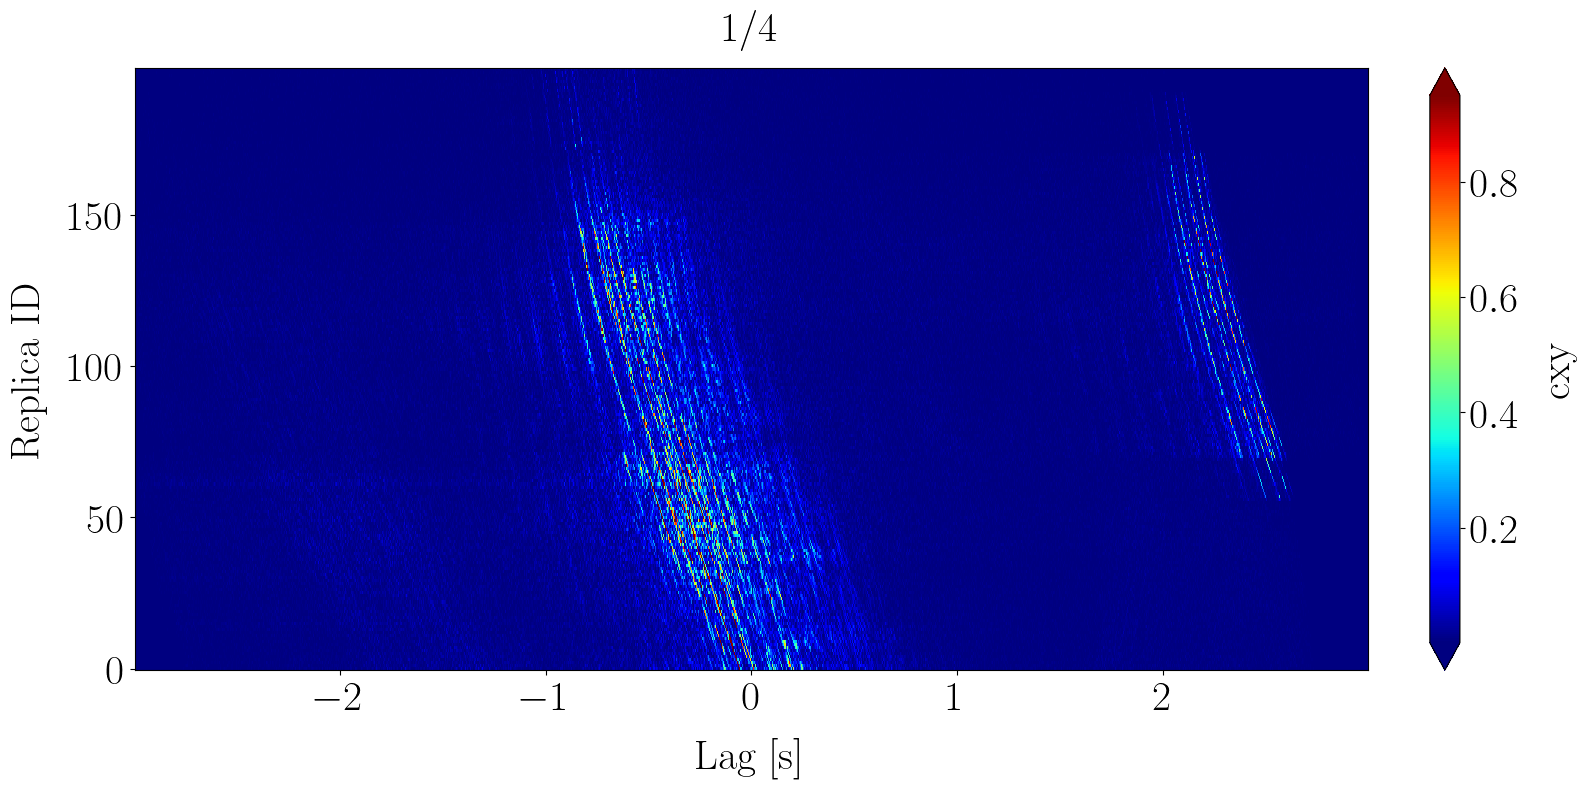

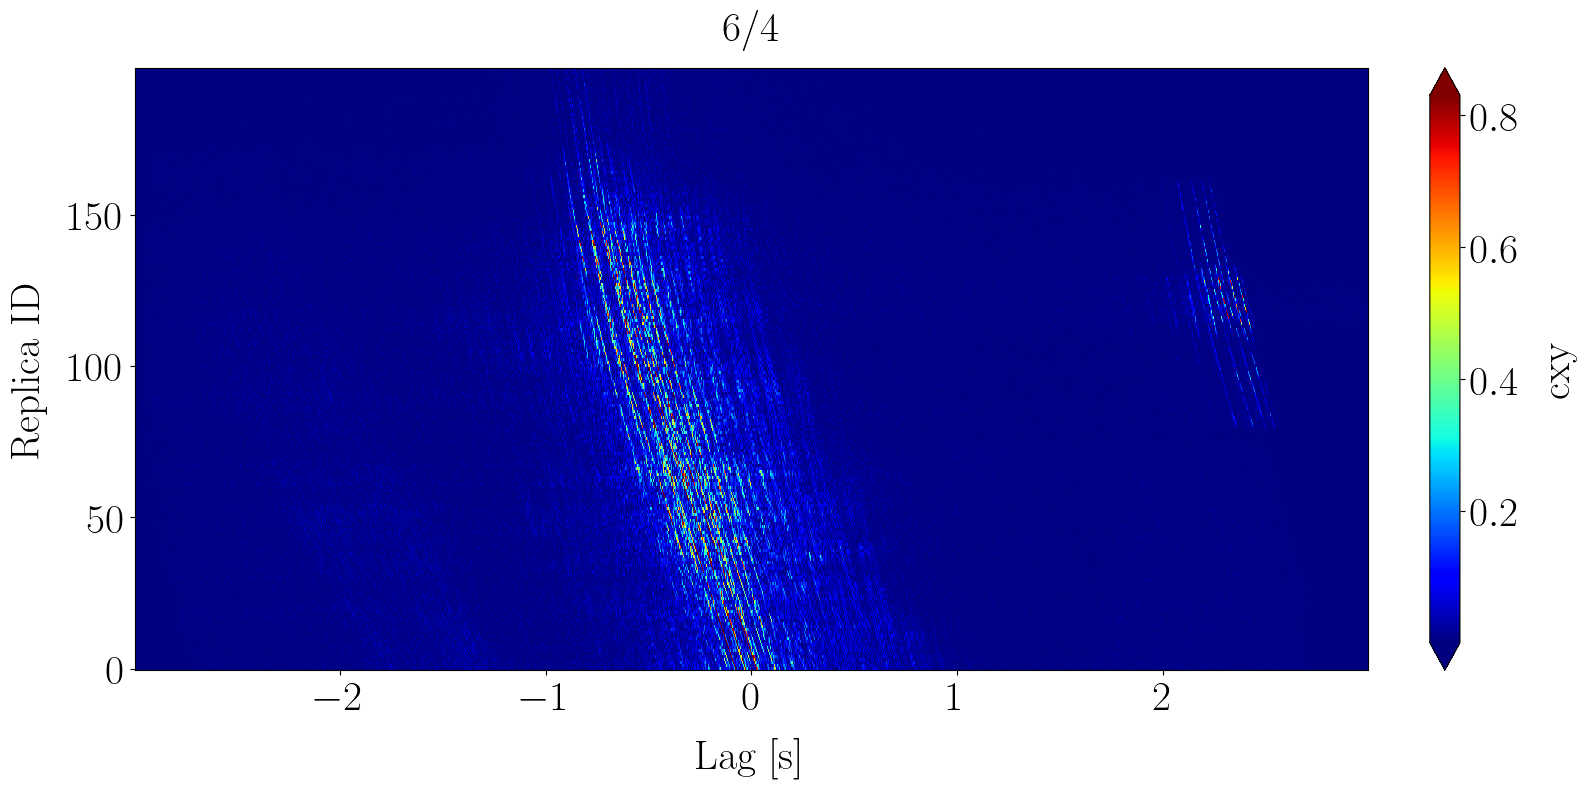

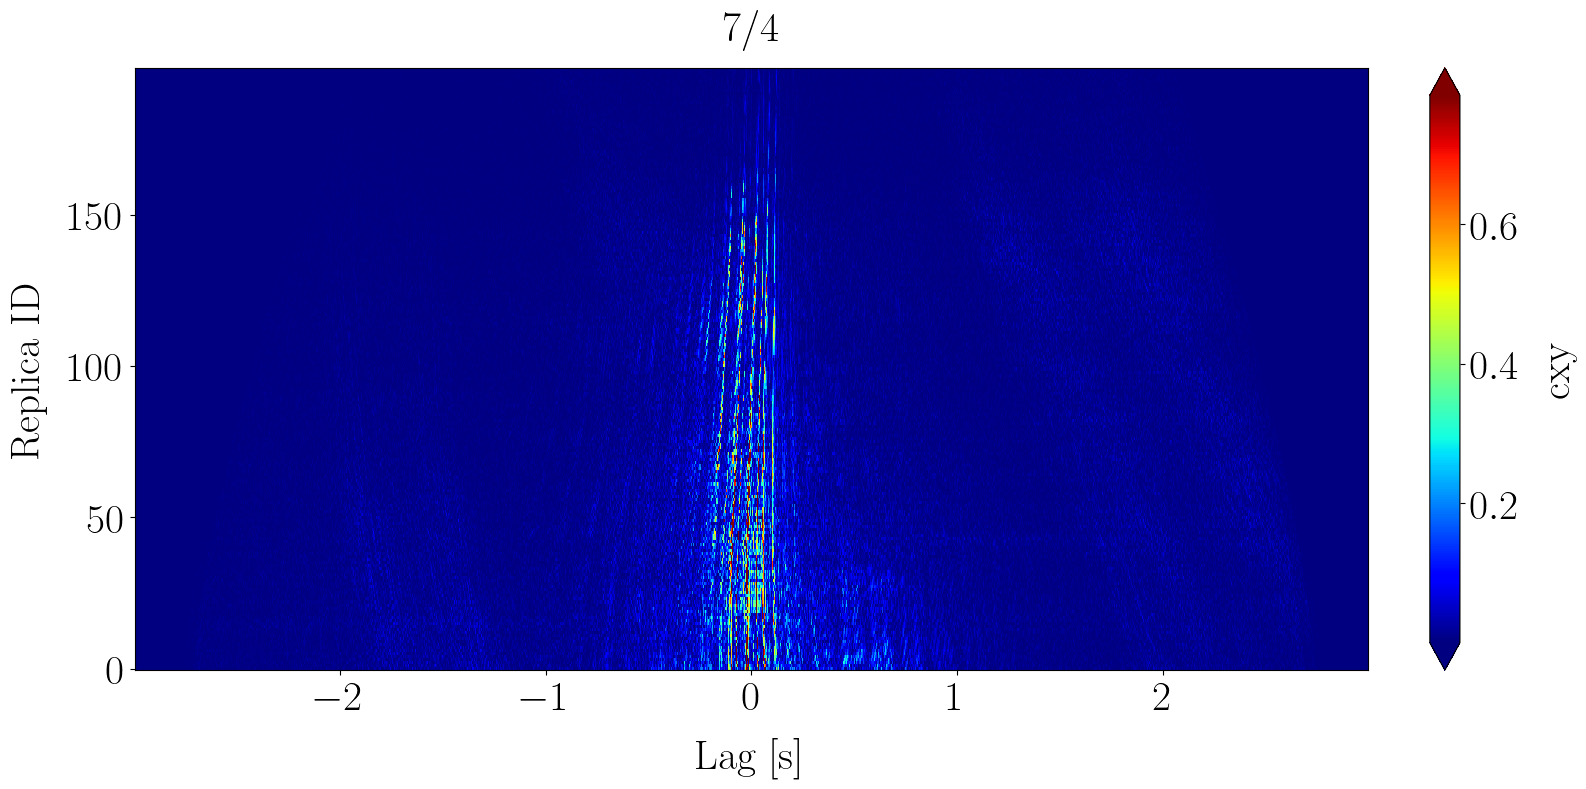

In [16]:
for rtf_id in ds_dcf.rtf_id.values:
    plot_cxy_map(ds_dcf, str(rtf_id), "shifted", percentiles=(5, 99.9))

Attention ici on a découpé avec des fenêtres arbitraires (on ne connait pas encore les instants d'émissions) pas d'interprétation possible des figures ci-dessus en termes de retard de propagation. 

In [ ]:
for rtf_id in ds_dcf.rtf_id.values:
    plot_sxy_map(ds_dcf, str(rtf_id), "shifted")

In [ ]:
np.real(ds_dcf.sxy_scot.sel(rtf_id="7/4").sel(pulse_id=0)).plot(x="freq")

In [ ]:
from sklearn.metrics import pairwise_distances

metric = "l2"
for rtf_id in ds_dcf.rtf_id.values:
    # coords = projected_coords[rtf_id]

    # l2_in_projection_space = pairwise_distances(coords, metric="l2")
    # l2_in_projection_space3D = pairwise_distances(coords[:, :3], metric="l2")
    # l2_in_original_space = pairwise_distances(ds_dcf.sel(rtf_id=rtf_id).sxy_scot, metric=metric)
    # l2_in_original_space = l2_in_original_space / np.max(l2_in_original_space) + 1e-6
    # l2_in_projection_space = (
    #     l2_in_projection_space / np.max(l2_in_projection_space) + 1e-6
    # )
    # l2_in_projection_space3D = (
    #     l2_in_projection_space3D / np.max(l2_in_projection_space3D) + 1e-6
    # )

    sxy = ds_dcf.sel(rtf_id=rtf_id).sxy_scot

    sxy = sxy.sel(pulse_id=slice(0, 100))

    dist_mat = np.abs(
        np.nansum(
            sxy.values[:, np.newaxis, :] * np.conj(sxy.values[np.newaxis, :, :]),
            axis=-1,
        )
    )
    dist_mat = dist_mat / np.max(dist_mat) + 1e-6
    # dist_mat = np.empty((sxy.sizes["pulse_id"], sxy.sizes["pulse_id"]))
    # # max_id =
    # for i in sxy.pulse_id.values:
    #     for j in range(i, np.max(sxy.pulse_id.values)+1):
    #         # print(i, j)
    #         sxy_ij = sxy.sel(pulse_id=i) * np.conj(sxy.sel(pulse_id=j))
    #         dij = np.real(np.sum(sxy_ij))
    #         dist_mat[i, j] = dij
    #         dist_mat[j, i] = dij

    vmin = -10

    fig, ax = plt.subplots(1, 1, figsize=(16, 8))

    im = ax.pcolormesh(
        # 10 * np.log10(dist_mat),
        dist_mat,
        cmap="magma",
        vmin=0,
        vmax=0.1,
        # vmin=vmin,
    )
    ax.set_title(f"d = D")

    plt.colorbar(im)
    i = 5
    plt.figure()
    # plt.plot(
    #     l2_in_projection_space[i, :],
    #     label="l2 in projection space (d = 100)",
    # )
    # plt.plot(
    #     l2_in_projection_space3D[i, :] / np.max(l2_in_projection_space3D[100, :]),
    #     label="l2 in projection space (d = 3)",
    # )
    plt.plot(
        dist_mat[i, :],
        label="l2 in original space",
    )
    plt.legend()

In [24]:
from sklearn import manifold
from sklearn.preprocessing import StandardScaler

# ISOMAP
n_components = 30
n_neighbors = 5
p = 2

# Define isomap object
isomap_obj = manifold.Isomap(
    n_neighbors=n_neighbors, n_components=n_components, p=p, metric="precomputed"
)

# Select input data
fmin = 10
fmax = 800



# Learn manifold and project data in target dimension
projected_coords = {}
for rtf_id in ds_dcf.rtf_id.values:

    sxy = ds_dcf.sel(rtf_id=rtf_id, freq=slice(fmin, fmax)).sxy_scot
    sxy = sxy.sel(pulse_id=slice(0, 100))

    dist_mat = np.abs(
        np.nansum(
            sxy.values[:, np.newaxis, :] * np.conj(sxy.values[np.newaxis, :, :]),
            axis=-1,
        )
    )
    dist_mat = dist_mat / np.max(dist_mat) + 1e-6

    # # Extract data
    # data = input_data.sel(rtf_id=rtf_id)
    # # Remove nan is any
    # rtf_contains_nan = np.sum(np.isnan(data), axis=1) > 0
    # rtf_without_nan = np.arange(data.sizes["pulse_id"])[~rtf_contains_nan]
    # data = data.isel(pulse_id=rtf_without_nan)
    # # Standardize
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(data)

    coords = isomap_obj.fit_transform(dist_mat)

    print(isomap_obj.reconstruction_error())
    # Normalize coords
    norm_factor = np.max(coords)
    coords /= norm_factor

    # Store
    projected_coords[str(rtf_id)] = coords

7.133115595584123e-06
1.0008605767222923e-05
5.6475446132378636e-05


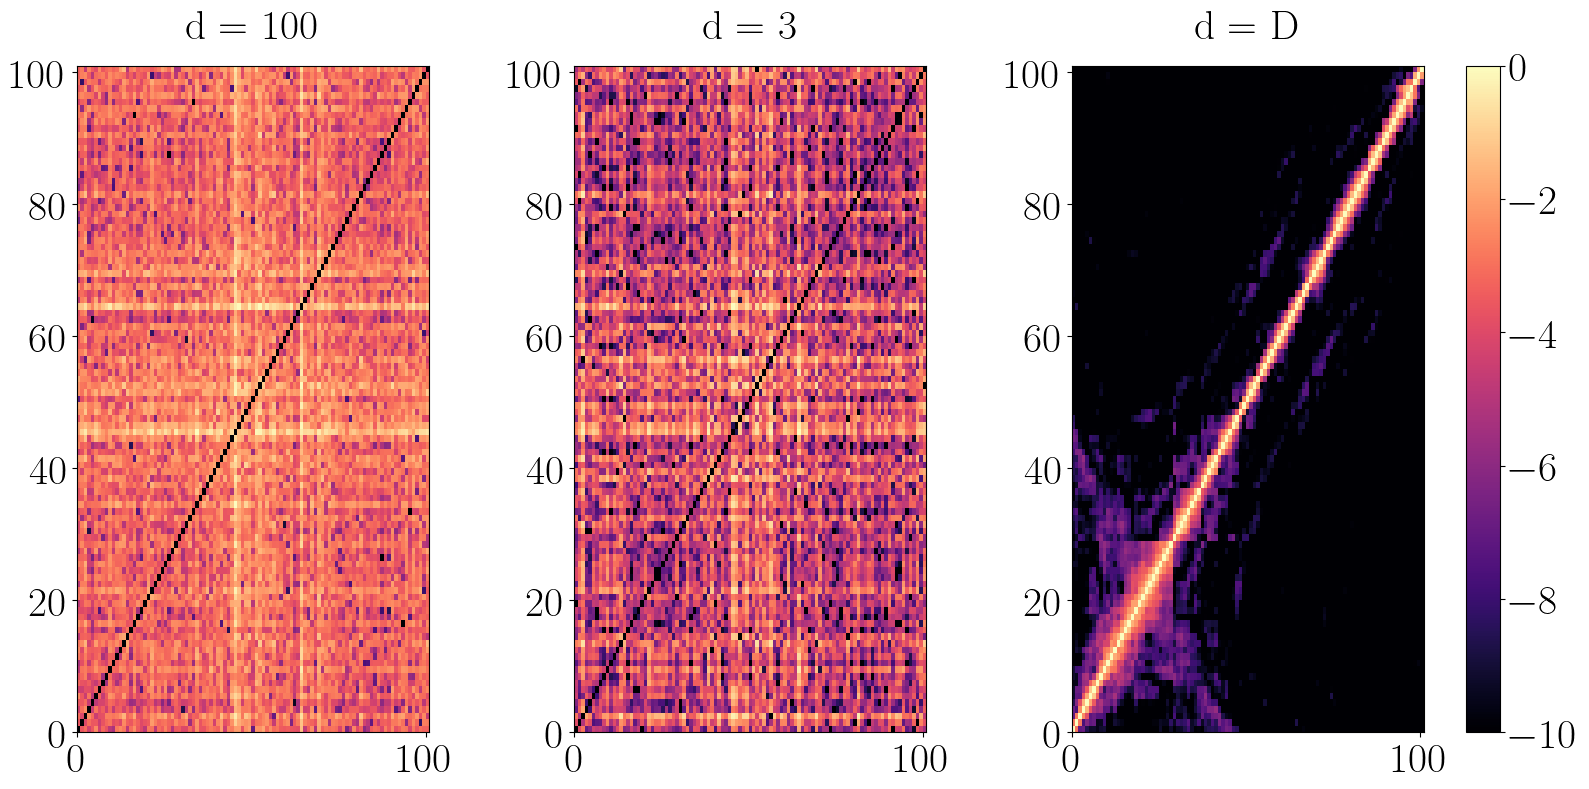

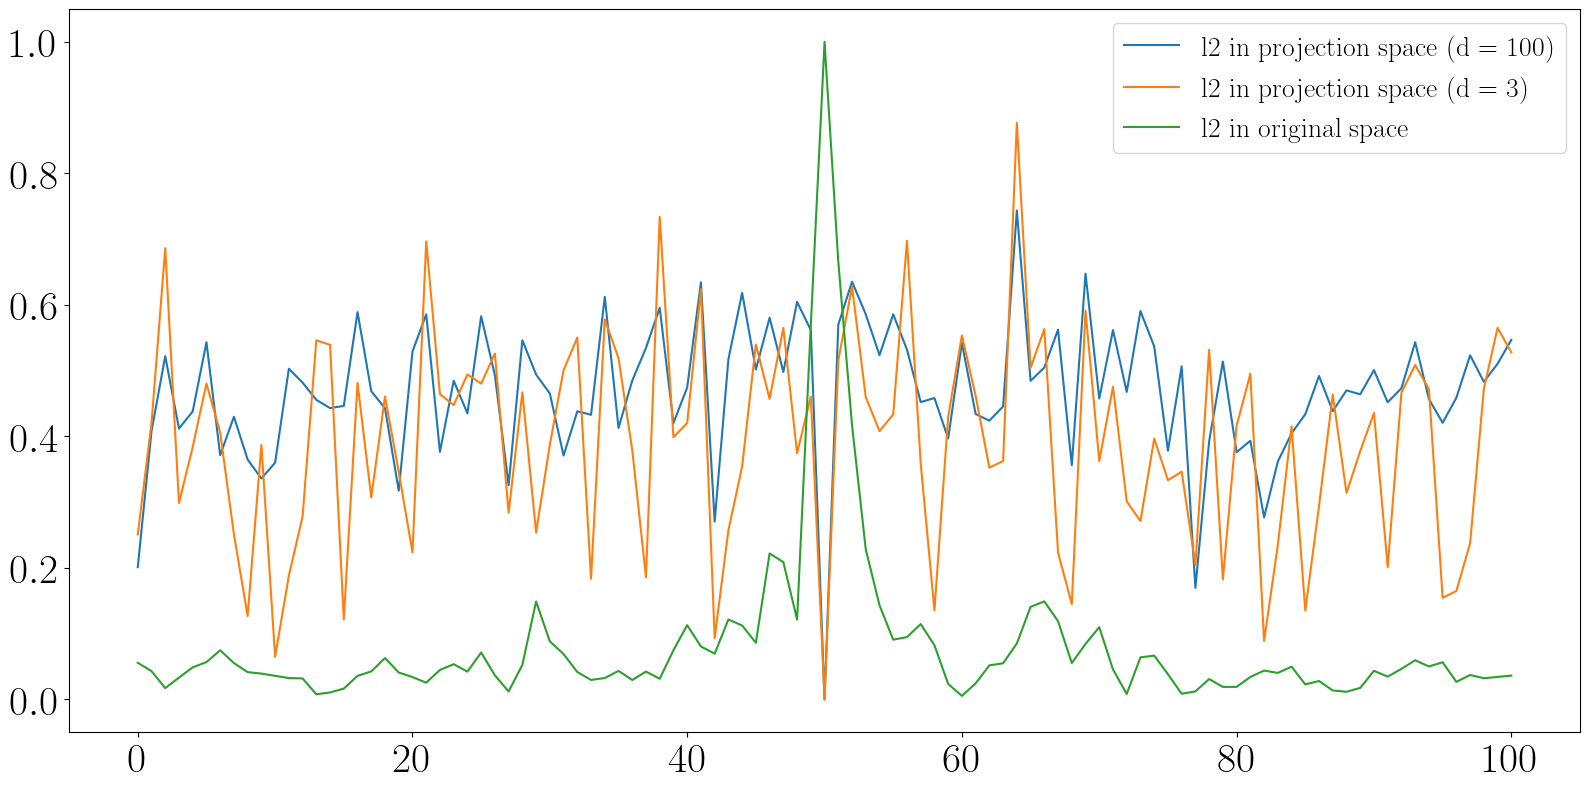

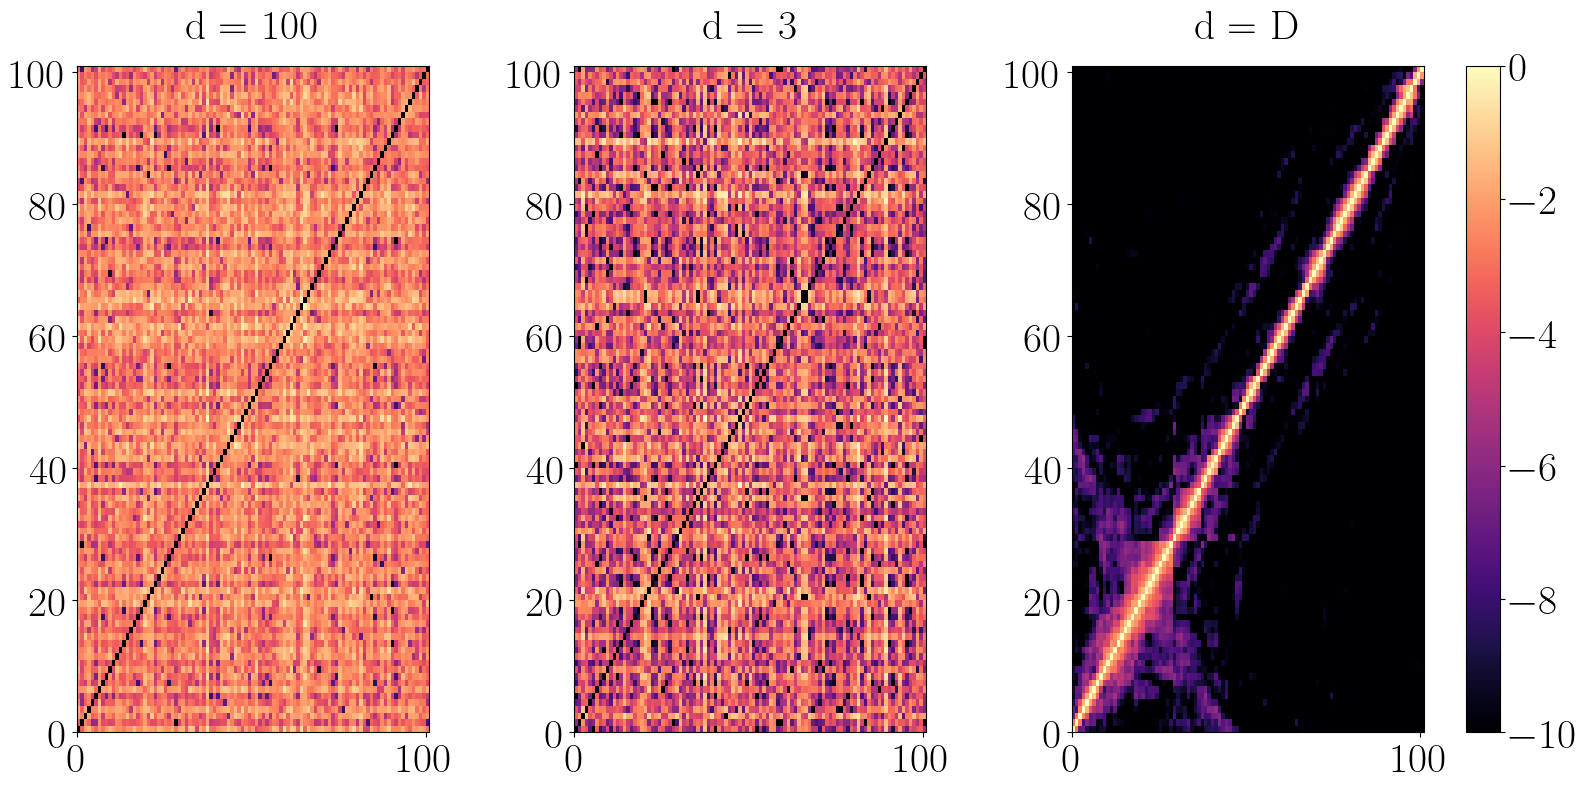

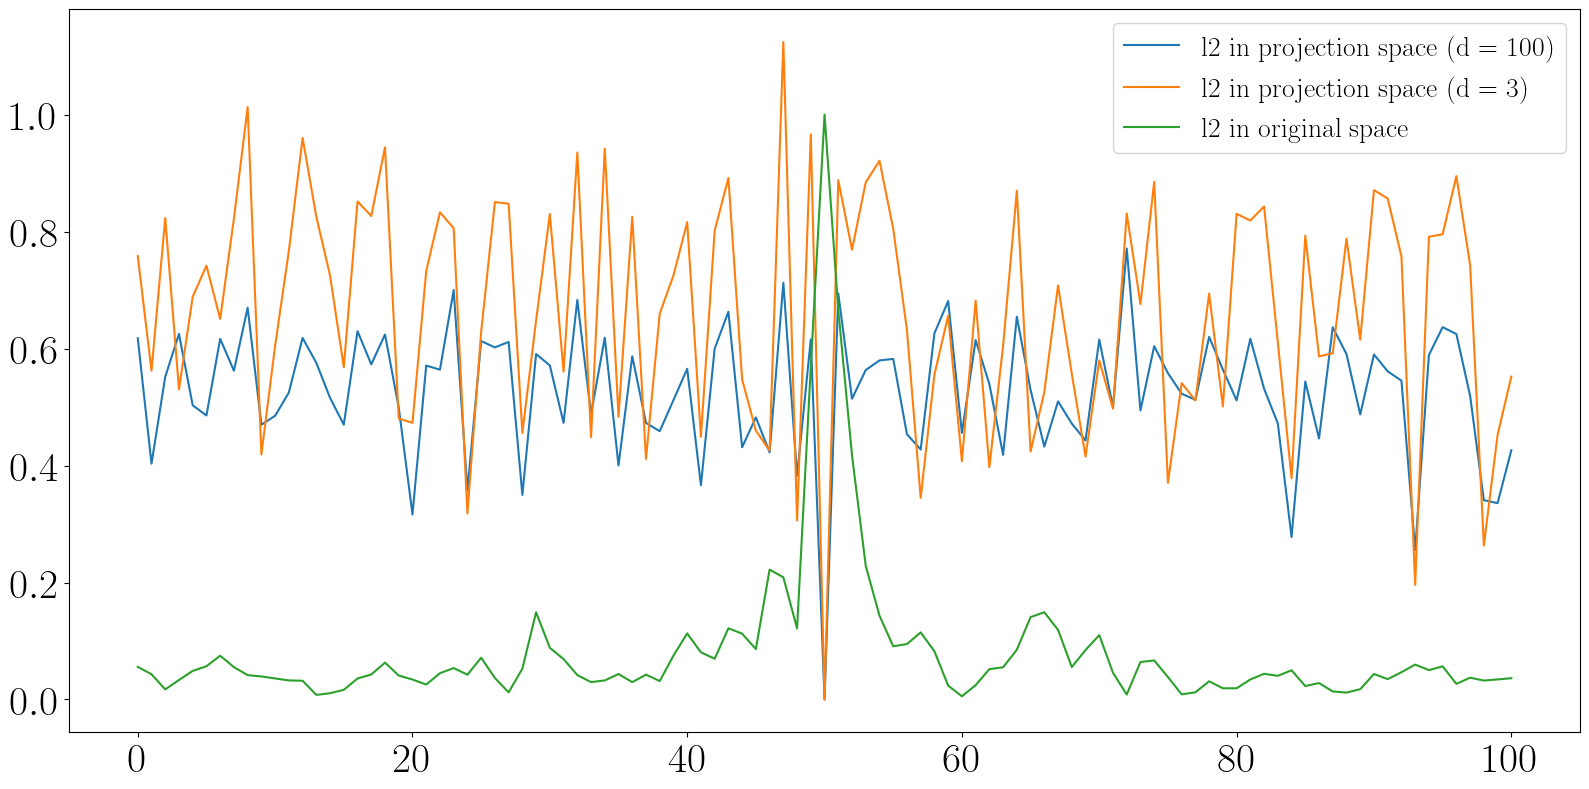

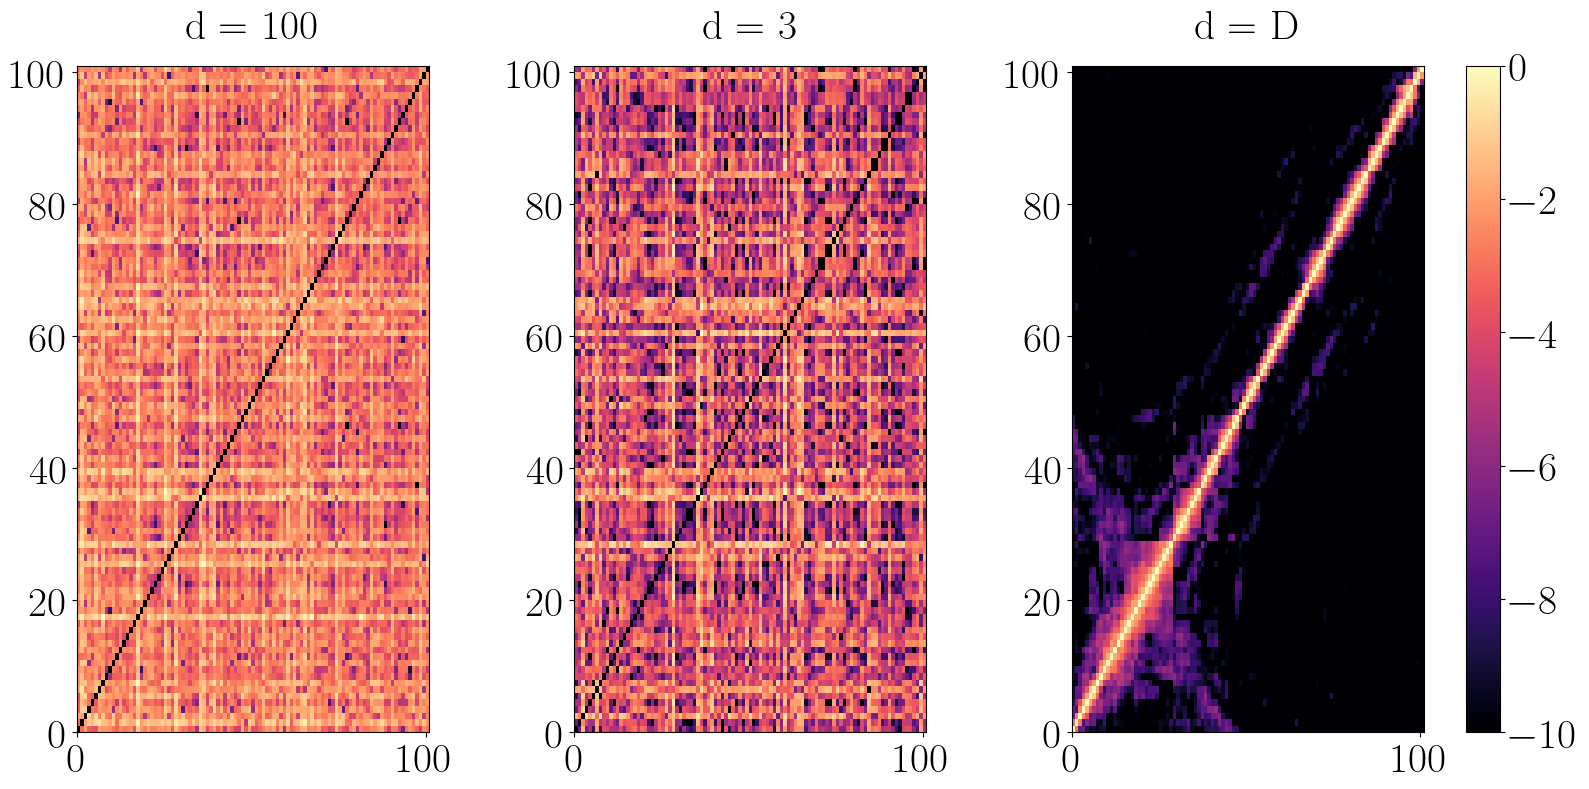

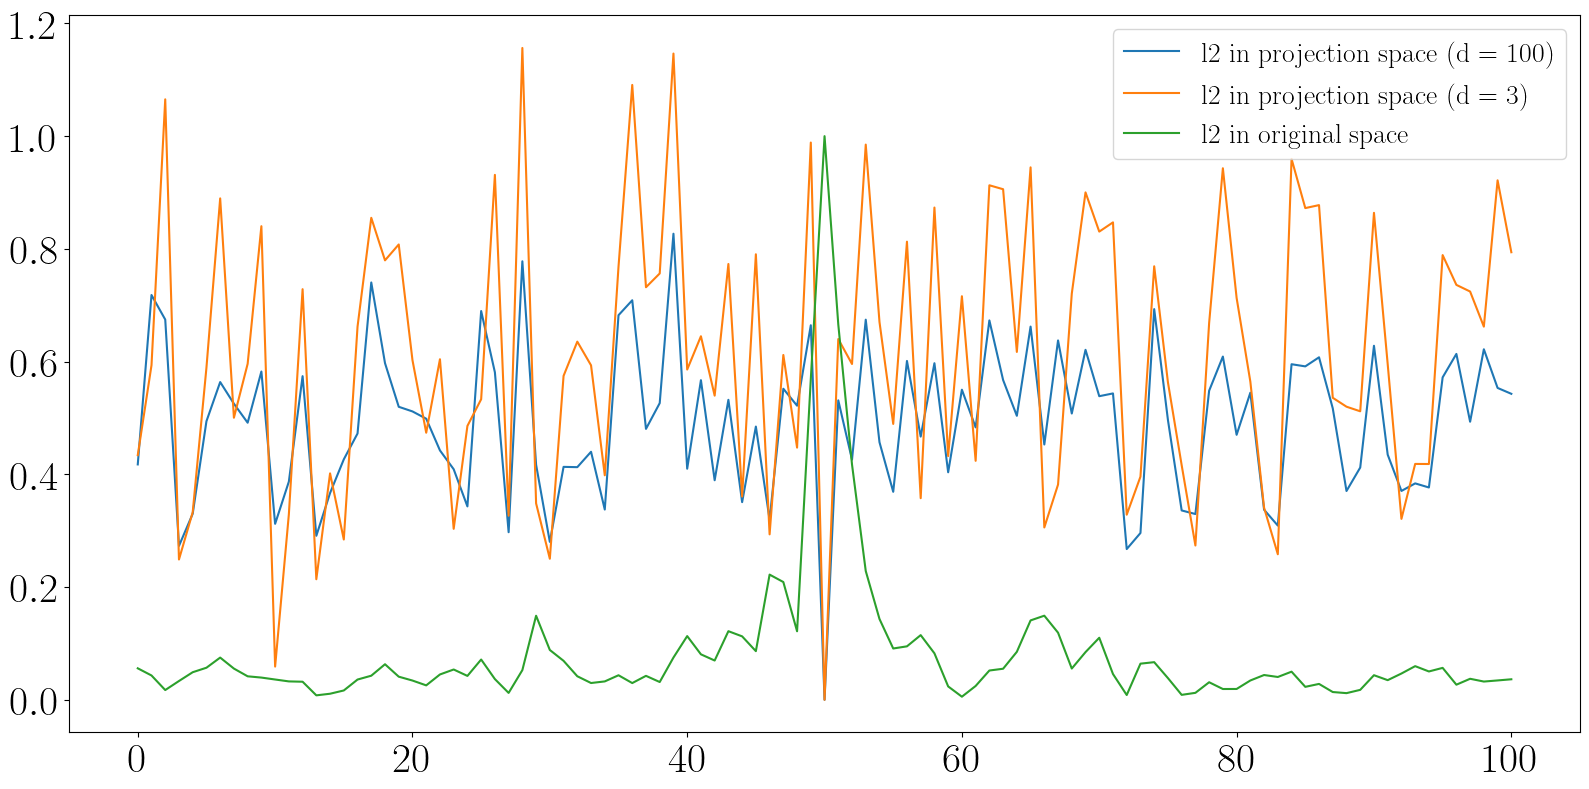

In [22]:
from sklearn.metrics import pairwise_distances

metric = "l2"
for rtf_id in ds_dcf.rtf_id.values:
    coords = projected_coords[rtf_id]

    l2_in_projection_space = pairwise_distances(coords, metric="l2")
    l2_in_projection_space3D = pairwise_distances(coords[:, :3], metric="l2")
    # l2_in_original_space = pairwise_distances(X_scaled, metric=metric)
    # l2_in_original_space = l2_in_original_space / np.max(l2_in_original_space) + 1e-6
    l2_in_projection_space = l2_in_projection_space / np.max(l2_in_projection_space) + 1e-6
    l2_in_projection_space3D = (
        l2_in_projection_space3D / np.max(l2_in_projection_space3D) + 1e-6
    )
    vmin = -10

    fig, axs = plt.subplots(1, 3, figsize=(16, 8))
    im = axs[0].pcolormesh(
        10 * np.log10(l2_in_projection_space),
        cmap="magma",
        vmax=0,
        vmin=vmin,
    )
    # plt.colorbar(im, ax=axs[0])
    axs[0].set_title(f"d = 100")

    im = axs[1].pcolormesh(
        10 * np.log10(l2_in_projection_space3D),
        cmap="magma",
        vmax=0,
        # vmin=np.percentile(10 * np.log10(l2_in_original_space), 10),
        vmin=vmin,
    )
    axs[1].set_title(f"d = 3")

    im = axs[2].pcolormesh(
        10 * np.log10(dist_mat),
        cmap="magma",
        vmax=0,
        # vmin=np.percentile(10 * np.log10(l2_in_original_space), 10),
        vmin=vmin,
    )
    axs[2].set_title(f"d = D")


    plt.colorbar(im)
    i = 50
    plt.figure()
    plt.plot(
        l2_in_projection_space[i, :],
        label="l2 in projection space (d = 100)",
    )
    plt.plot(
        l2_in_projection_space3D[i, :] / np.max(l2_in_projection_space3D[100, :]),
        label="l2 in projection space (d = 3)",
    )
    plt.plot(
        dist_mat[i, :],
        label="l2 in original space",
    )
    plt.legend()

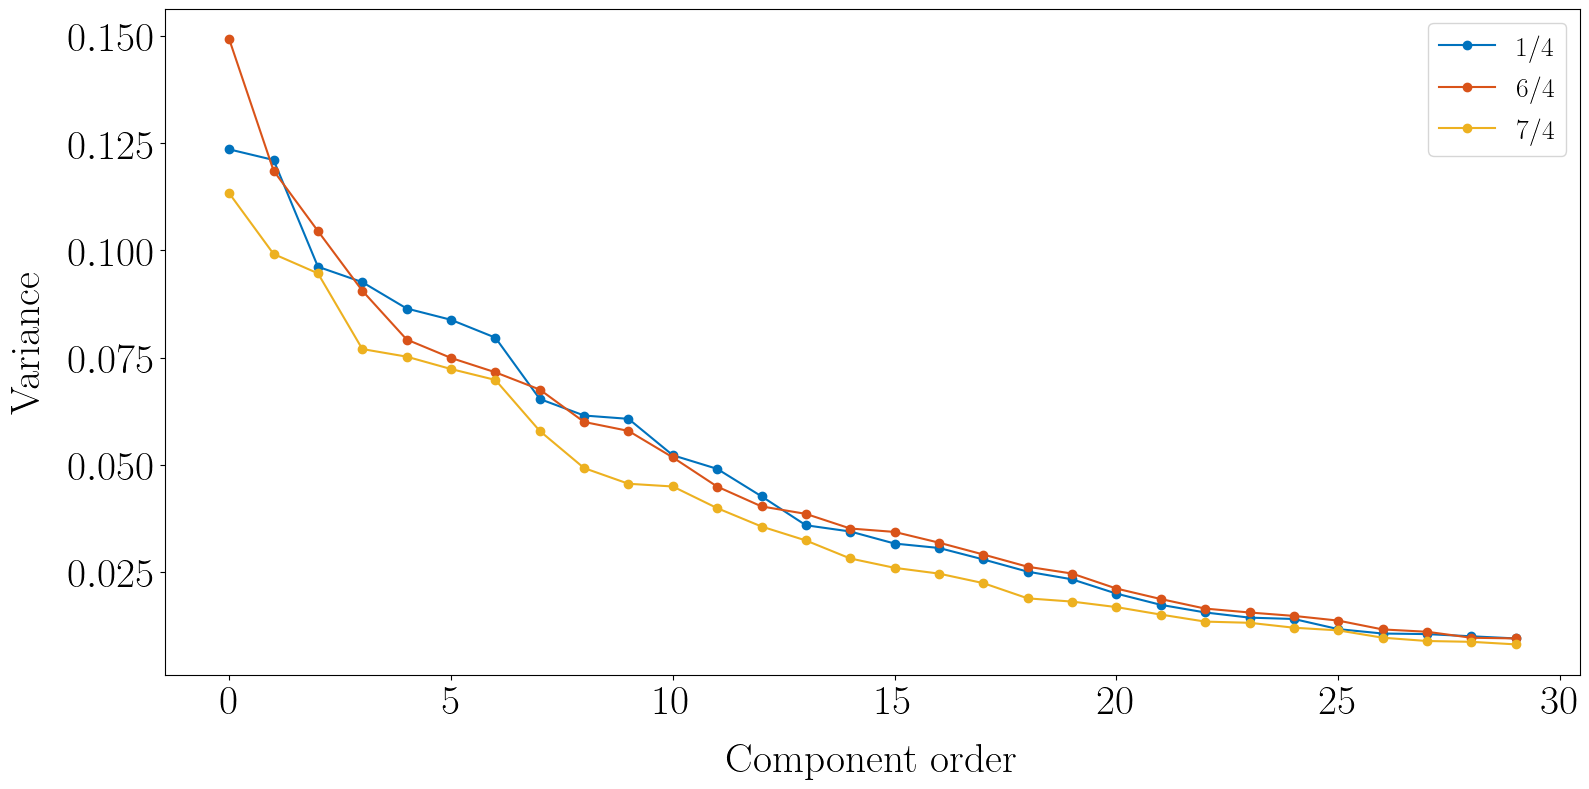

In [25]:
# Plot variance of each component
plt.figure()
cvar_coords = {}
for i, rtf_id in enumerate(ds_dcf.rtf_id.values):
    rtf_id = str(rtf_id)
    cvar = np.var(projected_coords[rtf_id], axis=0)
    cvar_coords[rtf_id] = cvar
    plt.plot(np.arange(cvar.size), cvar, marker="o", color=color(i), label=rtf_id)

plt.xlabel("Component order")
plt.ylabel("Variance")
plt.legend()

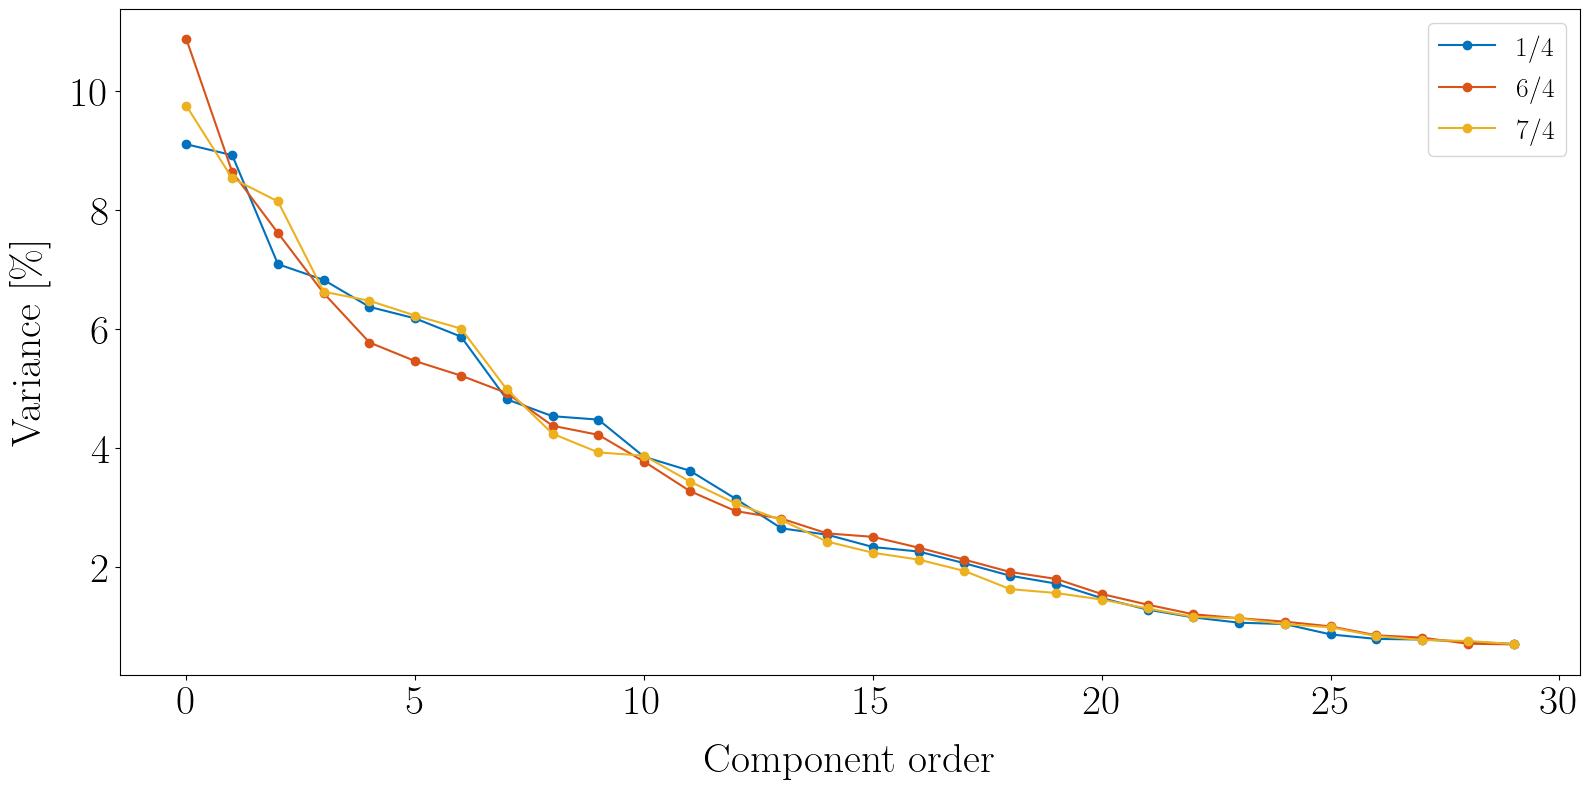

In [26]:
# Ratio de variance
cvar_ratio_coords = {}
cum_cvar_ratio_coords = {}
plt.figure()
for i, rtf_id in enumerate(ds_dcf.rtf_id.values):
    rtf_id = str(rtf_id)
    cvar = cvar_coords[rtf_id]
    cvar_tot = np.sum(cvar)
    cvar_ratio = cvar / cvar_tot
    cvar_ratio_coords[rtf_id] = cvar_ratio

    cum_cvar = np.cumsum(cvar_ratio)
    cum_cvar_ratio_coords[rtf_id] = cum_cvar

    plt.plot(np.arange(cvar.size), cvar_ratio*100, marker="o", color=color(i), label=rtf_id)

plt.xlabel("Component order")
plt.ylabel("Variance [\%]")
plt.legend()

In [ ]:
cvar[0] / cvar[-1]

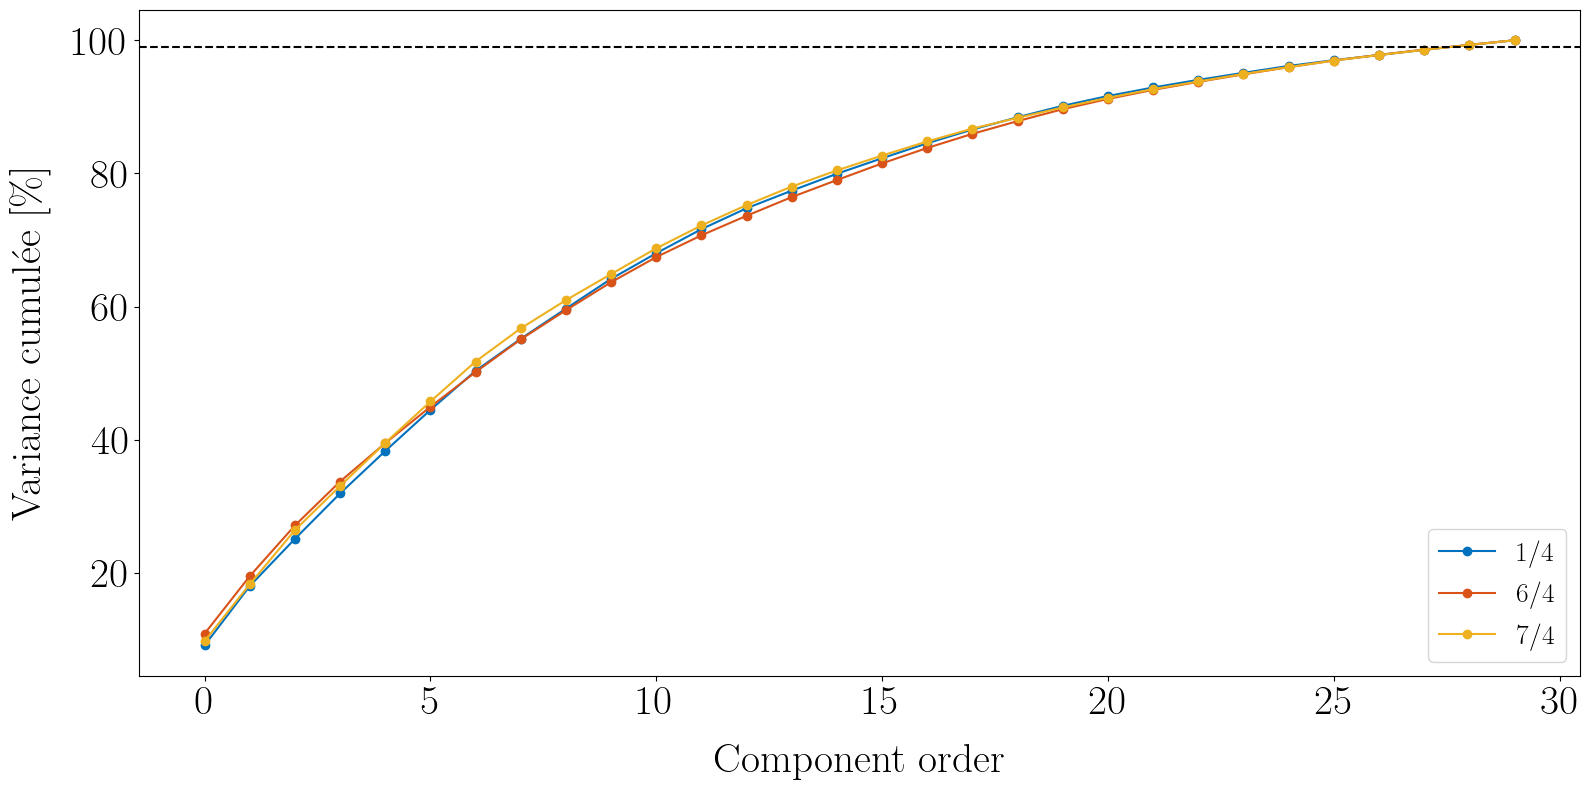

In [27]:
# Variance cumulée
cumulative_variance_threshold = 99
plt.figure()
for i, rtf_id in enumerate(ds_dcf.rtf_id.values):
    rtf_id = str(rtf_id)
    cum_cvar = cum_cvar_ratio_coords[rtf_id]
    plt.plot(np.arange(cvar.size), cum_cvar * 100, marker="o", color=color(i), label=rtf_id)

plt.xlabel("Component order")
plt.ylabel("Variance cumulée [\%]")
plt.axhline(cumulative_variance_threshold, linestyle="--", color="k")
plt.legend()

In [ ]:
# Compute info

# Variance explained by 3 components (hypothesis d = number of degree of freedom)
var_explained_3D = {}
for i, rtf_id in enumerate(ds_rtf.rtf_id.values):
    rtf_id = str(rtf_id)
    cum_cvar = cum_cvar_ratio_coords[rtf_id]
    cum_cvar_3D = cum_cvar[2]
    var_explained_3D[rtf_id] = cum_cvar_3D

# Number of component required to get over threshold
nb_component_for_th = {}
dimension_ratio_th = {}
for i, rtf_id in enumerate(ds_rtf.rtf_id.values):
    rtf_id = str(rtf_id)
    cum_cvar = cum_cvar_ratio_coords[rtf_id]
    # Determine the number of components needed to reach the threshold
    nb_comp_th = np.argmax(cum_cvar*100 >= cumulative_variance_threshold) + 1
    nb_component_for_th[rtf_id] = nb_comp_th
    # Get dimension ratio
    dim_ratio =   nb_comp_th / ds_rtf.sizes["freq"]
    print(dim_ratio)
    dimension_ratio_th[rtf_id] = dim_ratio

In [ ]:
# Print thresholds info
print(f"Recap manifold learning\n")
for i, rtf_id in enumerate(ds_rtf.rtf_id.values):
    rtf_id = str(rtf_id)
    print(f"RTF {rtf_id}:")
    print(
        f"\tPercentage of explained variance by the first 3 components = {var_explained_3D[rtf_id]*100:.1f}%"
    )
    print(
        f"\tNumber of components needed to reach the threshold ({cumulative_variance_threshold} %) = {nb_component_for_th[rtf_id]:.0f}"
    )
    print(f"\tDataset reduction of {(1 - dimension_ratio_th[rtf_id])*100:.3f} %")
    

**Bilan**

Toutes les combinaisons ont été testées : 

*metric="minkowski", p=2*


>Recap manifold learning
>
>RTF 7/1:
>	Percentage of explained variance by the first 3 components = 75.4%
>	Number of components needed to reach the threshold (99 %) = 49
>	Dataset reduction of 99.402 %
>RTF 6/1:
>	Percentage of explained variance by the first 3 components = 74.2%
>	Number of components needed to reach the threshold (99 %) = 51
>	Dataset reduction of 99.378 %
>RTF 4/1:
>	Percentage of explained variance by the first 3 components = 88.6%
>	Number of components needed to reach the threshold (99 %) = 33
>	Dataset reduction of 99.597 %
>
>Recap manifold learning
>
>RTF 1/7:
>	Percentage of explained variance by the first 3 components = 75.4%
>	Number of components needed to reach the threshold (99 %) = 49
>	Dataset reduction of 99.402 %
>RTF 6/7:
>	Percentage of explained variance by the first 3 components = 63.0%
>	Number of components needed to reach the threshold (99 %) = 59
>	Dataset reduction of 99.280 %
>RTF 4/7:
>	Percentage of explained variance by the first 3 components = 78.6%
>	Number of components needed to reach the threshold (99 %) = 40
>	Dataset reduction of 99.512 %
>
>Recap manifold learning
>
>RTF 1/4:
>	Percentage of explained variance by the first 3 components = 88.6%
>	Number of components needed to reach the threshold (99 %) = 33
>	Dataset reduction of 99.597 %
>RTF 6/4:
>	Percentage of explained variance by the first 3 components = 87.2%
>	Number of components needed to reach the threshold (99 %) = 29
>	Dataset reduction of 99.646 %
>RTF 7/4:
>	Percentage of explained variance by the first 3 components = 78.6%
>	Number of components needed to reach the threshold (99 %) = 40
>	Dataset reduction of 99.512 %
>
>Recap manifold learning
>
>RTF 1/6:
>	Percentage of explained variance by the first 3 components = 74.2%
>	Number of components needed to reach the threshold (99 %) = 51
>	Dataset reduction of 99.378 %
>RTF 4/6:
>	Percentage of explained variance by the first 3 components = 87.2%
>	Number of components needed to reach the threshold (99 %) = 29
>	Dataset reduction of 99.646 %
>RTF 7/6:
>	Percentage of explained variance by the first 3 components = 63.0%
>	Number of components needed to reach the threshold (99 %) = 59
>	Dataset reduction of 99.280 %

*metric="cosine"*

>Recap manifold learning
>
>RTF 7/1:
>	Percentage of explained variance by the first 3 components = 78.8%
>	Number of components needed to reach the threshold (99 %) = 49
>	Dataset reduction of 99.850 %
>RTF 6/1:
>	Percentage of explained variance by the first 3 components = 71.1%
>	Number of components needed to reach the threshold (99 %) = 53
>	Dataset reduction of 99.838 %
>RTF 4/1:
>	Percentage of explained variance by the first 3 components = 83.5%
>	Number of components needed to reach the threshold (99 %) = 38
>	Dataset reduction of 99.884 %
>
>Recap manifold learning
>
>RTF 1/7:
>	Percentage of explained variance by the first 3 components = 79.2%
>	Number of components needed to reach the threshold (99 %) = 48
>	Dataset reduction of 99.414 %
>RTF 6/7:
>	Percentage of explained variance by the first 3 components = 69.8%
>	Number of components needed to reach the threshold (99 %) = 52
>	Dataset reduction of 99.365 %
>RTF 4/7:
>	Percentage of explained variance by the first 3 components = 64.7%
>	Number of components needed to reach the threshold (99 %) = 50
>	Dataset reduction of 99.390 %
>
>Recap manifold learning
>
>RTF 1/4:
>	Percentage of explained variance by the first 3 components = 84.7%
>	Number of components needed to reach the threshold (99 %) = 37
>	Dataset reduction of 99.548 %
>RTF 6/4:
>	Percentage of explained variance by the first 3 components = 95.2%
>	Number of components needed to reach the threshold (99 %) = 13
>	Dataset reduction of 99.841 %
>RTF 7/4:
>	Percentage of explained variance by the first 3 components = 64.7%
>	Number of components needed to reach the threshold (99 %) = 50
>	Dataset reduction of 99.390 %
>
>Recap manifold learning
>
>RTF 1/6:
>	Percentage of explained variance by the first 3 components = 69.3%
>	Number of components needed to reach the threshold (99 %) = 55
>	Dataset reduction of 99.329 %
>RTF 4/6:
>	Percentage of explained variance by the first 3 components = 95.2%
>	Number of components needed to reach the threshold (99 %) = 13
>	Dataset reduction of 99.841 %
>RTF 7/6:
>	Percentage of explained variance by the first 3 components = 69.8%
>	Number of components needed to reach the threshold (99 %) = 52
>	Dataset reduction of 99.365 %

<!-- La réduction de dimension est la plus effective pour le choix du capteur 1 comme capteur de référence avec le plus haut pourcentage de variance expliquée par les trois premières composantes. Et un nombre de composantes requises pour atteindre le seuil à 99% légèrement plus faible que pour les autres capteurs. Ces différences sont toutefois minimes et le choix du capteur de référence semble ici anecdotique.  -->

<!-- On peut également remarquer que le pourcentage de variance expliquée par les 3 premières composantes traduit plutôt bien l'intuition visuelle. En effet, les RTF qui semblent le plus bruitées (rapport 6/1 ou 1/6 par exemple) sont associée à des faibles valeurs de ce critère.  -->

Pas de différences flagrantes à ce stade. 

## Convergence en fonction de l'erreur de reconstruction 

In [ ]:
n_neighbors = 5
p = 2


# Select input data
fmin = 10
fmax = 800
input_data = ds_rtf["gamma"].sel(window_mode="shifted", freq=slice(fmin, fmax))


reconstruction_error = {rtf_id: [] for rtf_id in ds_rtf.rtf_id.values}
n_test_components = np.arange(1, 101, 1)
for n_components in n_test_components:

    # Define isomap object
    # With Minkowski distance (equivalent to euclidean distance for p = 2)
    isomap_obj = manifold.Isomap(
        n_neighbors=n_neighbors,
        n_components=n_components,
        p=p,
    )
    # # With cosine distance
    # isomap_obj = manifold.Isomap(
    #     n_neighbors=n_neighbors,
    #     n_components=n_components,
    #     metric="cosine"
    # )

    for rtf_id in ds_rtf.rtf_id.values:
        # Extract data
        data = input_data.sel(rtf_id=rtf_id)
        # Remove nan is any
        rtf_contains_nan = np.sum(np.isnan(data), axis=1) > 0
        rtf_without_nan = np.arange(data.sizes["pulse_id"])[~rtf_contains_nan]
        data = data.isel(pulse_id=rtf_without_nan)
        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(data)
        coords = isomap_obj.fit_transform(X_scaled)

        # print(isomap_obj.reconstruction_error())
        reconstruction_error[rtf_id].append(isomap_obj.reconstruction_error())

In [ ]:
plt.figure()
for i, rtf_id in enumerate(ds_rtf.rtf_id.values):
    rtf_id = str(rtf_id)
    plt.plot(
        np.arange(len(reconstruction_error[rtf_id])),
        reconstruction_error[rtf_id],
        marker="o",
        color=color(i),
        label=rtf_id,
    )

plt.xlabel("Component order")
plt.ylabel("Reconstruction error")
plt.legend()

La structure de variété est clairement visible sur l'erreur de reconstruction. L'erreur de reconstruction atteint rapidement un niveau asymptotique lorsque la dimension de l'espace de projection augmente. 

## Apprentissage sur plusieurs vecteurs 

### Concaténation selon l'axe des fréquences

In [ ]:
# ISOMAP
n_components = 100
n_neighbors = 5
p = 2

# Define isomap object
# With Minkowski distance (equivalent to euclidean distance for p = 2)
isomap_obj = manifold.Isomap(
    n_neighbors=n_neighbors, n_components=n_components, p=p,
)
# # With cosine distance
# isomap_obj = manifold.Isomap(
#     n_neighbors=n_neighbors,
#     n_components=n_components,
#     metric="cosine"
# )

# Select input data
fmin = 10
fmax = 800
input_data = ds_rtf["gamma"].sel(
    window_mode="shifted", freq=slice(fmin, fmax)
)

input_data_parts = []
for rtf_id in ds_rtf.rtf_id.values:
    # Extract data
    data = input_data.sel(rtf_id=rtf_id)
    # Remove nan is any
    rtf_contains_nan = np.sum(np.isnan(data), axis=1) > 0
    rtf_without_nan = np.arange(data.sizes["pulse_id"])[~rtf_contains_nan]
    data = data.isel(pulse_id=rtf_without_nan)

    # # TODO check if necesseray 
    # data -= data.mean(dim="freq")
    
    input_data_parts.append(data.values)

input_data_concat = np.concat(input_data_parts, axis=1)

# Learn manifold and project data in target dimension

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(input_data_concat)
# Project 
coords = isomap_obj.fit_transform(X_scaled)

# Normalize coords
norm_factor = np.max(coords)
coords /= norm_factor


In [ ]:
coords

In [ ]:
# Plot variance of each component
cvar = np.var(projected_coords[rtf_id], axis=0)
plt.figure()
plt.plot(np.arange(cvar.size), cvar, marker="o", color="k")
plt.xlabel("Component order")
plt.ylabel("Variance")
plt.legend()

In [ ]:
cvar_tot = np.sum(cvar)
cvar_ratio = cvar / cvar_tot
cum_cvar = np.cumsum(cvar_ratio)

In [ ]:
# Variance cumulée
cumulative_variance_threshold = 99
plt.figure()
plt.plot(np.arange(cvar.size), cum_cvar * 100, marker="o", color="k")
plt.xlabel("Component order")
plt.ylabel("Variance cumulée [\%]")
plt.axhline(cumulative_variance_threshold, linestyle="--", color="k")
plt.legend()

In [ ]:
# Compute info
cum_cvar_3D = cum_cvar[2]
# Determine the number of components needed to reach the threshold
nb_comp_th = np.argmax(cum_cvar*100 >= cumulative_variance_threshold) + 1
# Get dimension ratio
dim_ratio = nb_comp_th / input_data_concat.shape[1]

In [ ]:
print(
    f"\tPercentage of explained variance by the first 3 components = {cum_cvar_3D*100:.1f}%"
)
print(
    f"\tNumber of components needed to reach the threshold ({cumulative_variance_threshold} %) = {nb_comp_th:.0f}"
)
print(f"\tDataset reduction of {(1 - dim_ratio)*100:.3f} %")

#### Convergence en fonction de l'erreur de reconstruction 

In [ ]:
# Select input data
fmin = 10
fmax = 800
input_data = ds_rtf["gamma"].sel(window_mode="shifted", freq=slice(fmin, fmax))

input_data_parts = []
for rtf_id in ds_rtf.rtf_id.values:
    # Extract data
    data = input_data.sel(rtf_id=rtf_id)
    # Remove nan is any
    rtf_contains_nan = np.sum(np.isnan(data), axis=1) > 0
    rtf_without_nan = np.arange(data.sizes["pulse_id"])[~rtf_contains_nan]
    data = data.isel(pulse_id=rtf_without_nan)

    input_data_parts.append(data.values)

input_data_concat = np.concat(input_data_parts, axis=1)


reconstruction_error = []
n_test_components = np.arange(1, 101, 1)
for n_components in n_test_components:

    # Define isomap object
    # With Minkowski distance (equivalent to euclidean distance for p = 2)
    isomap_obj = manifold.Isomap(
        n_neighbors=n_neighbors,
        n_components=n_components,
        p=p,
    )
    # # With cosine distance
    # isomap_obj = manifold.Isomap(
    #     n_neighbors=n_neighbors,
    #     n_components=n_components,
    #     metric="cosine"
    # )

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(input_data_concat)
    # Project 
    coords = isomap_obj.fit_transform(X_scaled)

    reconstruction_error.append(isomap_obj.reconstruction_error())

In [ ]:
plt.figure()

plt.plot(
    np.arange(len(reconstruction_error)),
    reconstruction_error,
    marker="o",
    color="k",
)

plt.xlabel("Component order")
plt.ylabel("Reconstruction error")
# plt.legend()

# Analyse des variations le long de la séquence 

In [ ]:
from sklearn.metrics import pairwise_distances

metric = "cosine"

l2_in_projection_space = pairwise_distances(coords, metric="l2")
l2_in_projection_space3D = pairwise_distances(coords[:, :10], metric="l2")
l2_in_original_space = pairwise_distances(X_scaled, metric=metric)

In [ ]:
l2_in_original_space = l2_in_original_space / np.max(l2_in_original_space) + 1e-6
l2_in_projection_space = l2_in_projection_space / np.max(l2_in_projection_space) + 1e-6
l2_in_projection_space3D = (
    l2_in_projection_space3D / np.max(l2_in_projection_space3D) + 1e-6
)

In [ ]:
vmin = -10

fig, axs = plt.subplots(1, 3, figsize=(16, 8))
im = axs[0].pcolormesh(
    10 * np.log10(l2_in_projection_space),
    cmap="magma",
    vmax=0,
    vmin=vmin,
)
# plt.colorbar(im, ax=axs[0])
axs[0].set_title(f"d = 100")

im = axs[1].pcolormesh(
    10 * np.log10(l2_in_projection_space3D),
    cmap="magma",
    vmax=0,
    # vmin=np.percentile(10 * np.log10(l2_in_original_space), 10),
    vmin=vmin,
)
axs[1].set_title(f"d = 3")

im = axs[2].pcolormesh(
    10 * np.log10(l2_in_original_space),
    cmap="magma",
    vmax=0,
    # vmin=np.percentile(10 * np.log10(l2_in_original_space), 10),
    vmin=vmin,
)
axs[2].set_title(f"d = D")


plt.colorbar(im)

In [ ]:
i = 300
plt.figure()
plt.plot(
    l2_in_projection_space[i, :],
    label="l2 in projection space (d = 100)",
)
plt.plot(
    l2_in_projection_space3D[i, :] / np.max(l2_in_projection_space3D[100, :]),
    label="l2 in projection space (d = 3)",
)
plt.plot(
    l2_in_original_space[i, :],
    label="l2 in original space",
)
plt.legend()

In [ ]:
plt.figure()
plt.plot(coords[:, 0], label=r"$\Psi_1$")
plt.plot(coords[:, 1], label=r"$\Psi_2$")
plt.plot(coords[:, 2], label=r"$\Psi_3$")
plt.legend()